# RARE: Research-Grade Agentic Retrieval Engine

A self-contained Kaggle notebook implementing a configurable, benchmarkable, and explainable retrieval engine for Agentic AI systems.

**Capabilities:**
- Multi-format document ingestion (PDF, DOCX, CSV, TXT, Markdown)
- 5 chunking strategies with ensemble support
- 4 retrieval methods with weighted fusion
- Query optimization (MultiQuery, HyDE, StepBack, Expansion)
- Ensemble reranking (BGE + CrossEncoder)
- Context compression (Redundancy removal, Contextual, LLM)
- Self-correcting retrieval with confidence-based retry loops
- LangGraph workflow orchestration with conditional routing
- Manual mode (full config control) and Agent mode (autonomous strategy selection)
- DeepEval evaluation with Ollama
- Benchmarking with CSV/leaderboard output
- LangSmith observability (optional)

## Section 1: Environment Setup
Install all required packages. This cell only needs to run once per Kaggle session.

In [1]:
import subprocess, sys, os

packages = [
    "langchain", "langchain-community", "langchain-experimental", "langchain-ollama",
    "langgraph",
    "qdrant-client",
    "rank_bm25",
    "pymupdf", "python-docx",
    "FlagEmbedding", "sentence-transformers",
    "deepeval",
    "langsmith",
    "tabulate",
    "duckduckgo-search",
    "ddgs",
    "zstd"
]

print("Installing packages...")
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg],
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
print("All packages installed.")

Installing packages...
All packages installed.


## Section 2: Ollama Setup
Install, start, and configure Ollama with health checks and model pull utilities.

In [29]:
import urllib.request
import subprocess
import time
import os
import shutil

def install_ollama():
    """Install Ollama on Linux (Kaggle environment)."""
    if shutil.which("ollama"):
        print("Ollama already installed")
        return True

    print("[OLLAMA] Installing...")
    os.system("apt-get update -qq")
    os.system("apt-get install -y zstd")

    ret = os.system("curl -fsSL https://ollama.com/install.sh | sh")

    if ret == 0:
        print("[OLLAMA] Installation complete.")
        return True
    print("[OLLAMA] Installation failed.")
    return False

def start_ollama():
    """Start Ollama server in background."""
    print("[OLLAMA] Starting server...")
    env = os.environ.copy()
    env["OLLAMA_SCHED_SPREAD"] = "1"
    env["CUDA_VISIBLE_DEVICES"] = "0,1"
    subprocess.Popen(["ollama", "serve"], env=env, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    for attempt in range(1, 16):
        try:
            resp = urllib.request.urlopen("http://localhost:11434/", timeout=2)
            if resp.getcode() == 200:
                print(f"[OLLAMA] Server ready (attempt {attempt}).")
                return True
        except Exception:
            print(f"[OLLAMA] Waiting... (attempt {attempt}/15)")
            time.sleep(2)
    print("[OLLAMA] Server failed to start.")
    return False

def pull_model(model_name):
    """Pull an Ollama model with status output."""
    print(f"[OLLAMA] Pulling model: {model_name}")
    result = subprocess.run(["ollama", "pull", model_name], capture_output=True, text=True)
    if result.returncode == 0:
        print(f"[OLLAMA] Model ready: {model_name}")
        return True
    print(f"[OLLAMA] Failed to pull {model_name}: {result.stderr[:200]}")
    return False

def check_ollama_health():
    """Verify Ollama is running and responsive."""
    try:
        resp = urllib.request.urlopen("http://localhost:11434/", timeout=5)
        return resp.getcode() == 200
    except Exception:
        return False

# Run setup
install_ollama()
start_ollama()

Ollama already installed
[OLLAMA] Starting server...
[OLLAMA] Waiting... (attempt 1/15)
[OLLAMA] Waiting... (attempt 2/15)
[OLLAMA] Server ready (attempt 3).


True

## Section 3: Core Imports

In [3]:
import time
import hashlib
import json
import re
import uuid
import warnings
import torch
from typing import List, Dict, Optional, Any, Literal, Tuple
from dataclasses import dataclass, field, asdict
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# LangChain / LangGraph
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_text_splitters import RecursiveCharacterTextSplitter, CharacterTextSplitter
from langgraph.graph import StateGraph, END
from sentence_transformers import CrossEncoder

# Vector store
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct, Filter, FieldCondition, MatchValue

# BM25
from rank_bm25 import BM25Okapi

# Web Search (for CRAG)
try:
    from langchain_community.tools import DuckDuckGoSearchResults
    from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
    _WEB_SEARCH_AVAILABLE = True
    print("[IMPORTS] DuckDuckGo web search available.")
except ImportError:
    _WEB_SEARCH_AVAILABLE = False
    print("[IMPORTS] DuckDuckGo web search NOT available. CRAG fallback disabled.")

print("[IMPORTS] All core imports successful.")

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


[IMPORTS] DuckDuckGo web search available.
[IMPORTS] All core imports successful.


## Section 4: Configuration

All system behavior is controlled from this cell. Change values here to completely reconfigure
the retrieval pipeline without modifying any source code.

**Modes:**
- `agent_mode: False` -- Manual mode. Uses the exact configuration specified below.
- `agent_mode: True` -- Agent mode. LLM autonomously selects strategies per query.

**Chunker/Retriever/Reranker weights** must sum to approximately 1.0.

In [4]:
# ---------------------------------------------------------------------------
# OLLAMA MODEL CONFIGURATION
# ---------------------------------------------------------------------------
OLLAMA_CONFIG = {
    "generation_model": "gemma2:2b",
    "query_optimizer_model": "gemma2:2b",
    "evaluation_model": "gemma2:2b",
}
device = "cuda" if torch.cuda.is_available() else "cpu"

HUGGINGFACE_CONFIG = {
    "embedding_model":"BAAI/bge-m3",
    "chunker_model":"BAAI/bge-m3"
}

# ---------------------------------------------------------------------------
# PIPELINE CONFIGURATION
# ---------------------------------------------------------------------------
# Available chunkers: semantic, parent_child, recursive, fixed, document_aware
# Available retrievers: dense, bm25, metadata, parent_child
# Available optimizers: multi_query, hyde, step_back, query_expansion
# Available rerankers: bge, cross_encoder
# Available compression: redundancy_removal, contextual, llm
CONFIG = {
    "agent_mode": False,

    "chunkers": {
        "semantic": 0.3,
        "parent_child": 0.5,
        "recursive": 0.2,
    },

    "retrievers": {
        "dense": 0.5,
        "bm25": 0.3,
        "metadata": 0.2,
    },

    "rerankers": {
        "bge": 0.7,
        "cross_encoder": 0.3,
    },

    "query_optimizers": [
        "multi_query",
        # "hyde",
        # "step_back",
    ],

    "compression": "contextual",

    "top_k_retrieval": 30,
    "top_k_reranked": 15,
    "confidence_threshold": 0.75,
    "max_retries": 3,
}

# ---------------------------------------------------------------------------
# DOCUMENT PATHS
# ---------------------------------------------------------------------------
DOCUMENTS = [
    # Paths will be auto-populated by sample document generator below.
    # Replace with your own document paths as needed.
    "/kaggle/input/datasets/shivanshcoding/rag-dataset-with-evaluation/rbi_notification.pdf"
]

# ---------------------------------------------------------------------------
# LANGSMITH CONFIGURATION (auto-detected)
# ---------------------------------------------------------------------------
LANGSMITH_CONFIG = {
    "project": "RARE",
    "enabled": False,
}

# ---------------------------------------------------------------------------
# RERANKER MODEL CONFIGURATION
# ---------------------------------------------------------------------------
RERANKER_CONFIG = {
    "bge": 0.7,
    "cross_encoder": 0.3,
    "bge_model": "BAAI/bge-reranker-v2-m3",
    "cross_encoder_model": "cross-encoder/ms-marco-MiniLM-L-6-v2",
}

# Pull configured Ollama models
for _model in set(OLLAMA_CONFIG.values()):
    pull_model(_model)

print("\n--- CONFIGURATION LOADED ---")
print(f"Agent Mode       : {CONFIG['agent_mode']}")
print(f"Generation Model : {OLLAMA_CONFIG['generation_model']}")
print(f"Embedding Model  : {HUGGINGFACE_CONFIG['embedding_model']}")
print(f"Chunking Model   : {HUGGINGFACE_CONFIG['chunker_model']}")
print(f"Chunkers         : {list(CONFIG['chunkers'].keys())}")
print(f"Retrievers       : {list(CONFIG['retrievers'].keys())}")
print(f"Rerankers        : {list(CONFIG['rerankers'].keys())}")
print(f"Optimizers       : {CONFIG['query_optimizers']}")
print(f"Compression      : {CONFIG['compression']}")
print(f"Top K Retrieval  : {CONFIG['top_k_retrieval']}")
print(f"Top K Reranked   : {CONFIG['top_k_reranked']}")
print(f"Confidence Thresh: {CONFIG['confidence_threshold']}")
print("--- END ---")

[OLLAMA] Pulling model: gemma2:2b
[OLLAMA] Model ready: gemma2:2b

--- CONFIGURATION LOADED ---
Agent Mode       : False
Generation Model : gemma2:2b
Embedding Model  : BAAI/bge-m3
Chunking Model   : BAAI/bge-m3
Chunkers         : ['semantic', 'parent_child', 'recursive']
Retrievers       : ['dense', 'bm25', 'metadata']
Rerankers        : ['bge', 'cross_encoder']
Optimizers       : ['multi_query']
Compression      : contextual
Top K Retrieval  : 30
Top K Reranked   : 15
Confidence Thresh: 0.75
--- END ---


## Section 5: LangSmith Observability (Optional)

Configures LangSmith tracing if the API key is available via Kaggle Secrets.
The system never fails due to missing LangSmith credentials.

In [5]:
import os

def configure_langsmith():
    """Configure LangSmith. Silently disables if unavailable."""
    try:
        from kaggle_secrets import UserSecretsClient
        secrets = UserSecretsClient()
        api_key = secrets.get_secret("LANGSMITH_API_KEY")
        if api_key and api_key.strip():
            os.environ["LANGCHAIN_TRACING_V2"] = "true"
            os.environ["LANGCHAIN_API_KEY"] = api_key
            os.environ["LANGCHAIN_PROJECT"] = LANGSMITH_CONFIG["project"]
            LANGSMITH_CONFIG["enabled"] = True
            print("--- LANGSMITH ---")
            print(f"Status  : Enabled")
            print(f"Project : {LANGSMITH_CONFIG['project']}")
            print("--- END ---")
            return True
    except Exception:
        pass
    LANGSMITH_CONFIG["enabled"] = False
    print("--- LANGSMITH ---")
    print("Status  : Disabled")
    print("--- END ---")
    return False

configure_langsmith()

--- LANGSMITH ---
Status  : Enabled
Project : RARE
--- END ---


True

In [6]:
@dataclass
class ScoredDocument:
    """A document with a relevance score and provenance metadata."""
    content: str
    score: float
    metadata: Dict[str, Any] = field(default_factory=dict)
    source_retriever: str = ""

    def to_langchain(self) -> Document:
        meta = {**self.metadata, "score": self.score, "source_retriever": self.source_retriever}
        return Document(page_content=self.content, metadata=meta)

@dataclass
class PipelineTrace:
    """Telemetry container for a single query execution."""
    query: str = ""
    query_type: str = ""
    chunkers_used: List[str] = field(default_factory=list)
    retrievers_used: List[str] = field(default_factory=list)
    optimizers_used: List[str] = field(default_factory=list)
    rerankers_used: List[str] = field(default_factory=list)
    compression_strategy: str = ""
    confidence_score: float = 0.0
    coverage_score: float = 0.0
    context_quality: float = 0.0
    docs_retrieved: int = 0
    docs_after_rerank: int = 0
    docs_final: int = 0
    retry_count: int = 0
    web_search_used: bool = False
    node_latencies: Dict[str, float] = field(default_factory=dict)
    total_latency: float = 0.0

print("[DATACLASSES] Defined ScoredDocument, PipelineTrace.")

[DATACLASSES] Defined ScoredDocument, PipelineTrace.


## Section 6: Sample Document Generation
Creates synthetic sample documents for demonstration and testing.

In [7]:
import csv

SAMPLE_DIR = "/kaggle/working/sample_docs"
os.makedirs(SAMPLE_DIR, exist_ok=True)

# --- Sample TXT ---
SAMPLE_TXT = """Retrieval-Augmented Generation (RAG) is an AI framework that enhances large language
model outputs by incorporating external knowledge retrieval. RAG systems first retrieve relevant
documents from a knowledge base, then use those documents as context for generating responses.

Key components of a RAG pipeline include: document ingestion, text chunking, embedding generation,
vector storage, retrieval, reranking, and response generation. Each component can be individually
optimized to improve overall system performance.

Dense retrieval uses embedding similarity to find semantically relevant passages. BM25 retrieval
uses term frequency and inverse document frequency for keyword-based matching. Hybrid retrieval
combines both approaches for improved recall.

Chunking strategies significantly impact retrieval quality. Fixed-size chunking is simple but may
split sentences mid-thought. Semantic chunking preserves meaning by splitting at natural boundaries.
Parent-child chunking maintains hierarchical context by linking small retrieval units to larger
parent documents.

Reranking is a critical post-retrieval step that reorders documents using cross-encoder models.
Cross-encoders jointly encode the query and document, producing more accurate relevance scores
than bi-encoder approaches, at the cost of higher computational expense.

Query optimization techniques include multi-query generation, where the original query is
rephrased into multiple variants to improve recall. HyDE (Hypothetical Document Embeddings)
generates a hypothetical answer and uses it as a search query. Step-back prompting creates
a more abstract version of the query to capture broader context.
"""
txt_path = os.path.join(SAMPLE_DIR, "rag_overview.txt")
with open(txt_path, "w") as f:
    f.write(SAMPLE_TXT)

# --- Sample Markdown ---
SAMPLE_MD = """# Vector Database Architecture

## Overview
Vector databases are specialized storage systems designed for high-dimensional embedding vectors.
They enable fast approximate nearest neighbor (ANN) search, which is fundamental to modern
retrieval systems.

## Indexing Strategies

### HNSW (Hierarchical Navigable Small World)
HNSW constructs a multi-layer graph where each node represents a vector. The top layers contain
fewer nodes for fast coarse navigation, while bottom layers contain all nodes for precise search.
HNSW offers excellent query performance with logarithmic complexity.

### IVF (Inverted File Index)
IVF partitions the vector space into clusters using k-means. During search, only a subset of
clusters are scanned, trading recall for speed. IVF-PQ combines clustering with product
quantization for memory-efficient storage.

## Distance Metrics
- **Cosine Similarity**: Measures angle between vectors. Best for normalized embeddings.
- **Euclidean Distance**: Measures straight-line distance. Sensitive to magnitude.
- **Dot Product**: Fastest computation. Requires normalized vectors for meaningful results.

## Production Considerations
Scaling vector databases requires careful attention to index build time, memory consumption,
and query latency. Sharding across multiple nodes enables horizontal scaling. Replication
provides fault tolerance and read throughput.
"""
md_path = os.path.join(SAMPLE_DIR, "vector_db_arch.md")
with open(md_path, "w") as f:
    f.write(SAMPLE_MD)

# --- Sample CSV ---
csv_path = os.path.join(SAMPLE_DIR, "eval_questions.csv")
csv_rows = [
    ["question", "category", "difficulty"],
    ["What is RAG?", "conceptual", "easy"],
    ["How does HNSW indexing work?", "technical", "medium"],
    ["Compare dense and BM25 retrieval", "comparative", "medium"],
    ["What are the production considerations for vector databases?", "procedural", "hard"],
    ["Explain the difference between cosine similarity and euclidean distance", "conceptual", "medium"],
    ["What is parent-child chunking?", "technical", "easy"],
    ["How does HyDE query optimization work?", "technical", "medium"],
    ["What is cross-encoder reranking?", "technical", "medium"],
]
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerows(csv_rows)

# --- Sample PDF (using PyMuPDF) ---
pdf_path = os.path.join(SAMPLE_DIR, "chunking_strategies.pdf")
try:
    import fitz
    doc = fitz.open()
    page = doc.new_page(width=612, height=792)
    text_page1 = """Chunking Strategies for RAG Systems

1. Fixed-Size Chunking
Fixed-size chunking splits text into equal-length segments with optional overlap.
While simple to implement, it risks splitting sentences and paragraphs at
arbitrary points, potentially degrading retrieval quality.

Parameters: chunk_size (characters), chunk_overlap (characters)
Typical values: chunk_size=512, chunk_overlap=50

2. Recursive Character Splitting
This strategy attempts to split on natural boundaries in order of preference:
double newlines, single newlines, periods, spaces. It preserves paragraph
structure better than fixed-size chunking while maintaining size limits.

3. Semantic Chunking
Semantic chunking uses embedding similarity to detect topic boundaries. It
computes embeddings for each sentence, then identifies breakpoints where the
cosine similarity between consecutive sentences drops below a threshold. This
produces chunks that are semantically coherent."""
    p = fitz.Point(72, 72)
    page.insert_text(p, text_page1, fontsize=11)

    page2 = doc.new_page(width=612, height=792)
    text_page2 = """4. Parent-Child Chunking
Parent-child chunking creates a two-level hierarchy. Large parent chunks
(1000-2000 characters) provide broad context, while small child chunks
(200-400 characters) serve as retrieval units. When a child chunk is
retrieved, its parent is returned to provide richer context.

5. Document-Aware Chunking
This strategy adapts chunking behavior based on document type:
- PDF: Respects page boundaries
- Markdown: Splits by header hierarchy
- CSV: Each row becomes a separate chunk
- Code: Splits by function/class boundaries

Ensemble Chunking
Multiple chunking strategies can be combined in an ensemble. Each chunker
produces its own set of chunks, which are stored in separate vector
collections. During retrieval, results from all collections are fused
using Reciprocal Rank Fusion (RRF) with configurable weights."""
    page2.insert_text(fitz.Point(72, 72), text_page2, fontsize=11)
    doc.save(pdf_path)
    doc.close()
except Exception as e:
    print(f"[SAMPLE] PDF generation skipped: {e}")
    pdf_path = None

# --- Sample DOCX ---
docx_path = os.path.join(SAMPLE_DIR, "evaluation_methods.docx")
try:
    from docx import Document as DocxDocument
    ddoc = DocxDocument()
    ddoc.add_heading("RAG Evaluation Methods", level=1)
    ddoc.add_heading("Faithfulness", level=2)
    ddoc.add_paragraph(
        "Faithfulness measures whether the generated answer is grounded in the retrieved "
        "context. A faithful answer does not contain claims that cannot be attributed to "
        "the provided documents. This metric is critical for preventing hallucinations."
    )
    ddoc.add_heading("Context Precision", level=2)
    ddoc.add_paragraph(
        "Context precision evaluates whether the relevant documents are ranked higher in "
        "the retrieved set. High precision means the most useful documents appear first, "
        "reducing noise in the generation context window."
    )
    ddoc.add_heading("Context Recall", level=2)
    ddoc.add_paragraph(
        "Context recall measures whether all the necessary information to answer the query "
        "is present in the retrieved documents. Low recall indicates missing information "
        "that may lead to incomplete answers."
    )
    ddoc.add_heading("Answer Relevancy", level=2)
    ddoc.add_paragraph(
        "Answer relevancy assesses whether the generated response directly addresses the "
        "user query. An answer may be faithful to the context but irrelevant to the "
        "actual question being asked."
    )
    ddoc.add_heading("Hallucination Detection", level=2)
    ddoc.add_paragraph(
        "Hallucination detection identifies claims in the generated answer that are not "
        "supported by the retrieved context. This is measured by decomposing the answer "
        "into individual claims and checking each against the source documents."
    )
    ddoc.save(docx_path)
except Exception as e:
    print(f"[SAMPLE] DOCX generation skipped: {e}")
    docx_path = None

# Populate DOCUMENTS list
# DOCUMENTS.clear()
for p in [txt_path, md_path, csv_path, pdf_path, docx_path]:
    if p and os.path.exists(p):
        DOCUMENTS.append(p)

print(f"[SAMPLE] Generated {len(DOCUMENTS)} sample documents in {SAMPLE_DIR}")
for d in DOCUMENTS:
    print(f"  - {os.path.basename(d)}")

[SAMPLE] Generated 6 sample documents in /kaggle/working/sample_docs
  - rbi_notification.pdf
  - rag_overview.txt
  - vector_db_arch.md
  - eval_questions.csv
  - chunking_strategies.pdf
  - evaluation_methods.docx


## Section 7: Document Ingestion

Automatically detects document type, loads content, and extracts metadata.

In [8]:
class DocumentLoader:
    """Load and parse documents from multiple formats with metadata extraction."""

    SUPPORTED = {".pdf", ".docx", ".csv", ".txt", ".md"}

    def load(self, paths: List[str]) -> List[Document]:
        all_docs = []
        for path in paths:
            ext = os.path.splitext(path)[1].lower()
            if ext not in self.SUPPORTED:
                print(f"[LOADER] Skipping unsupported format: {path}")
                continue
            try:
                loader = {
                    ".pdf": self._load_pdf,
                    ".docx": self._load_docx,
                    ".csv": self._load_csv,
                    ".txt": self._load_txt,
                    ".md": self._load_markdown,
                }[ext]
                docs = loader(path)
                for doc in docs:
                    doc.metadata.update(self._base_metadata(doc, path, ext))
                all_docs.extend(docs)
                print(f"[LOADER] {os.path.basename(path)}: {len(docs)} document(s)")
            except Exception as e:
                print(f"[LOADER] Error loading {path}: {e}")
        return all_docs

    def _base_metadata(self, doc: Document, path: str, ext: str) -> dict:
        return {
            "source": os.path.basename(path),
            "source_path": path,
            "doc_type": ext.lstrip("."),
            "word_count": len(doc.page_content.split()),
            "char_count": len(doc.page_content),
        }

    def _load_pdf(self, path: str) -> List[Document]:
        import fitz
        docs = []
        pdf = fitz.open(path)
        for i, page in enumerate(pdf):
            text = page.get_text().strip()
            if text:
                docs.append(Document(page_content=text, metadata={"page": i + 1}))
        pdf.close()
        return docs

    def _load_docx(self, path: str) -> List[Document]:
        from docx import Document as DDoc
        ddoc = DDoc(path)
        paragraphs = [p.text.strip() for p in ddoc.paragraphs if p.text.strip()]
        # Group consecutive paragraphs into sections by headings
        sections, current = [], []
        for para in ddoc.paragraphs:
            if para.style.name.startswith("Heading") and current:
                sections.append("\n".join(current))
                current = []
            if para.text.strip():
                current.append(para.text.strip())
        if current:
            sections.append("\n".join(current))
        if not sections:
            sections = ["\n".join(paragraphs)]
        return [Document(page_content=s, metadata={"section": i + 1}) for i, s in enumerate(sections)]

    def _load_csv(self, path: str) -> List[Document]:
        df = pd.read_csv(path)
        docs = []
        for i, row in df.iterrows():
            content = " | ".join(f"{col}: {val}" for col, val in row.items())
            meta = {col: str(val) for col, val in row.items()}
            meta["row_index"] = i
            docs.append(Document(page_content=content, metadata=meta))
        return docs

    def _load_txt(self, path: str) -> List[Document]:
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
        paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
        if not paragraphs:
            return [Document(page_content=text)]
        return [Document(page_content=p, metadata={"paragraph": i + 1})
                for i, p in enumerate(paragraphs)]

    def _load_markdown(self, path: str) -> List[Document]:
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
        sections = re.split(r'\n(?=#{1,3}\s)', text)
        docs = []
        for i, section in enumerate(sections):
            section = section.strip()
            if not section:
                continue
            header_match = re.match(r'^(#{1,3})\s+(.*)', section)
            header = header_match.group(2) if header_match else f"section_{i}"
            docs.append(Document(page_content=section, metadata={"section_header": header}))
        return docs if docs else [Document(page_content=text)]

# --- Run Ingestion ---
loader = DocumentLoader()
raw_documents = loader.load(DOCUMENTS)

print(f"\n--- INGESTION SUMMARY ---")
print(f"Documents Loaded : {len(raw_documents)}")
type_counts = defaultdict(int)
for d in raw_documents:
    type_counts[d.metadata.get("doc_type", "unknown")] += 1
for t, c in type_counts.items():
    print(f"  {t.upper():>8}: {c}")
print(f"Total Words      : {sum(d.metadata.get('word_count', 0) for d in raw_documents)}")
print("--- END ---")

[LOADER] rbi_notification.pdf: 330 document(s)
[LOADER] rag_overview.txt: 6 document(s)
[LOADER] vector_db_arch.md: 7 document(s)
[LOADER] eval_questions.csv: 8 document(s)
[LOADER] chunking_strategies.pdf: 2 document(s)
[LOADER] evaluation_methods.docx: 6 document(s)

--- INGESTION SUMMARY ---
Documents Loaded : 359
       PDF: 332
       TXT: 6
        MD: 7
       CSV: 8
      DOCX: 6
Total Words      : 93360
--- END ---


## Section 8: Advanced Chunking

Five chunking strategies with ensemble support. Each chunker tags output with
`chunker_type` metadata. Ensemble mode stores chunks from each strategy separately.

In [9]:
class FixedChunker:
    """Fixed-size chunking with configurable size and overlap."""
    name = "fixed"
    def __init__(self, chunk_size=1024, chunk_overlap=250):
        self.splitter = CharacterTextSplitter(
            chunk_size=chunk_size, chunk_overlap=chunk_overlap,
            separator="\n\n"
        )
    def chunk(self, documents: List[Document]) -> List[Document]:
        chunks = self.splitter.split_documents(documents)
        for c in chunks:
            c.metadata["chunker_type"] = self.name
        return chunks

class RecursiveChunker:
    """Recursive splitting with natural language separators."""
    name = "recursive"
    def __init__(self, chunk_size=800, chunk_overlap=100):
        self.splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size, chunk_overlap=chunk_overlap,
            separators=["\n\n", "\n", ". ", ", ", " ", ""]
        )
    def chunk(self, documents: List[Document]) -> List[Document]:
        chunks = self.splitter.split_documents(documents)
        for c in chunks:
            c.metadata["chunker_type"] = self.name
        return chunks

class SemanticChunker:
    """Embedding-based semantic boundary detection."""
    name = "semantic"
    def __init__(self):
        self._fallback = RecursiveChunker()
        try:
            from langchain_experimental.text_splitter import SemanticChunker as SC
            self.splitter = SC(
                HuggingFaceBgeEmbeddings(
                    model_name=HUGGINGFACE_CONFIG["chunker_model"],
                    model_kwargs={"device": "cuda"},
                    encode_kwargs={"batch_size": 128, "normalize_embeddings": True}
                ),
                breakpoint_threshold_type="percentile",
            )
            self._available = True
        except Exception as e:
            print(f"[CHUNKER] SemanticChunker unavailable, using fallback: {e}")
            self._available = False

    def chunk(self, documents: List[Document]) -> List[Document]:
        if not self._available:
            chunks = self._fallback.chunk(documents)
            for c in chunks:
                c.metadata["chunker_type"] = self.name
            return chunks
        try:
            chunks = self.splitter.split_documents(documents)
            for c in chunks:
                c.metadata["chunker_type"] = self.name
            return chunks
        except Exception:
            chunks = self._fallback.chunk(documents)
            for c in chunks:
                c.metadata["chunker_type"] = self.name
            return chunks

class ParentChildChunker:
    """Two-level hierarchy: large parents for context, small children for retrieval."""
    name = "parent_child"
    def __init__(self, parent_size=1500, child_size=300, child_overlap=50):
        self.parent_splitter = RecursiveCharacterTextSplitter(
            chunk_size=parent_size, chunk_overlap=0
        )
        self.child_splitter = RecursiveCharacterTextSplitter(
            chunk_size=child_size, chunk_overlap=child_overlap
        )
        self.parent_store = {}  # parent_id -> parent_content

    def chunk(self, documents: List[Document]) -> List[Document]:
        self.parent_store.clear()
        all_children = []
        parent_chunks = self.parent_splitter.split_documents(documents)
        for i, parent in enumerate(parent_chunks):
            parent_id = hashlib.md5(parent.page_content[:200].encode()).hexdigest()[:12]
            self.parent_store[parent_id] = parent.page_content
            children = self.child_splitter.split_documents([parent])
            for child in children:
                child.metadata["chunker_type"] = self.name
                child.metadata["parent_id"] = parent_id
                child.metadata["parent_index"] = i
            all_children.extend(children)
        return all_children

class DocumentAwareChunker:
    """Adapts chunking strategy based on document type."""
    name = "document_aware"
    def __init__(self):
        self.recursive = RecursiveChunker()

    def chunk(self, documents: List[Document]) -> List[Document]:
        all_chunks = []
        for doc in documents:
            doc_type = doc.metadata.get("doc_type", "txt")
            if doc_type == "csv":
                doc.metadata["chunker_type"] = self.name
                all_chunks.append(doc)
            elif doc_type == "md":
                # Already split by headers in loader; just tag
                doc.metadata["chunker_type"] = self.name
                all_chunks.append(doc)
            else:
                chunks = self.recursive.chunk([doc])
                for c in chunks:
                    c.metadata["chunker_type"] = self.name
                all_chunks.extend(chunks)
        return all_chunks

CHUNKER_REGISTRY = {
    "fixed": FixedChunker,
    "recursive": RecursiveChunker,
    "semantic": SemanticChunker,
    "parent_child": ParentChildChunker,
    "document_aware": DocumentAwareChunker,
}

print("[CHUNKERS] Registered:", list(CHUNKER_REGISTRY.keys()))

[CHUNKERS] Registered: ['fixed', 'recursive', 'semantic', 'parent_child', 'document_aware']


In [10]:
class ChunkEnsemble:
    """Orchestrates multiple chunkers. Produces separate chunk sets per strategy."""

    def __init__(self, chunker_config: dict):
        self.config = chunker_config
        self.chunkers = {}
        for name in chunker_config:
            if name in CHUNKER_REGISTRY:
                self.chunkers[name] = CHUNKER_REGISTRY[name]()
            else:
                print(f"[ENSEMBLE] Unknown chunker: {name}")
        self.parent_stores = {} 

    def chunk(self, documents: List[Document]) -> Dict[str, List[Document]]:
        results = {}
        for name, chunker in self.chunkers.items():
            t0 = time.time()
            chunks = chunker.chunk(documents)
            elapsed = time.time() - t0
            results[name] = chunks
            if hasattr(chunker, "parent_store"):
                self.parent_stores[name] = chunker.parent_store
            print(f"[CHUNK] {name:>15}: {len(chunks):>5} chunks ({elapsed:.2f}s)")
        return results

# --- Run Chunking ---
chunk_ensemble = ChunkEnsemble(CONFIG["chunkers"])
chunked_docs = chunk_ensemble.chunk(raw_documents)

total_chunks = sum(len(v) for v in chunked_docs.values())
print(f"\n--- CHUNKING SUMMARY ---")
print(f"Total Chunk Sets : {len(chunked_docs)}")
print(f"Total Chunks     : {total_chunks}")
for name, chunks in chunked_docs.items():
    avg_len = np.mean([len(c.page_content) for c in chunks]) if chunks else 0
    print(f"  {name:>15}: {len(chunks)} chunks, avg {avg_len:.0f} chars")
print("--- END ---")

/tmp/ipykernel_132/336469395.py:37: LangChainDeprecationWarning: The class `HuggingFaceBgeEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  HuggingFaceBgeEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

[CHUNK]        semantic:   679 chunks (129.35s)
[CHUNK]    parent_child:  2633 chunks (0.07s)
[CHUNK]       recursive:  1041 chunks (0.03s)

--- CHUNKING SUMMARY ---
Total Chunk Sets : 3
Total Chunks     : 4353
         semantic: 679 chunks, avg 907 chars
     parent_child: 2633 chunks, avg 241 chars
        recursive: 1041 chunks, avg 643 chars
--- END ---


## Section 9: Vector Store (Qdrant Local)

Stores embeddings in Qdrant running in local mode. Each chunker strategy gets its own collection.

In [11]:
class VectorStoreManager:
    """Manages Qdrant collections for document storage and retrieval."""

    def __init__(self, path="/kaggle/working/qdrant_data"):
        self.client = QdrantClient(path=path)
        self.embedder = HuggingFaceBgeEmbeddings(
            model_name=HUGGINGFACE_CONFIG["embedding_model"],
            model_kwargs={"device": device},
            encode_kwargs={"batch_size": 32, "normalize_embeddings": True}
        )
        self._dim = None
        self.collections = {}

    def _get_dim(self) -> int:
        if self._dim is None:
            test = self.embedder.embed_query("dimension test")
            self._dim = len(test)
        return self._dim

    def create_collection(self, name: str, chunks: List[Document], batch_size: int = 32):
        """Embed and store chunks in a named collection. Deletes existing collection first."""
        collection_name = f"rare_{name}"
        dim = self._get_dim()

        # Always delete existing collection before creating new
        try:
            self.client.delete_collection(collection_name)
        except Exception:
            pass
        self.client.create_collection(
            collection_name=collection_name,
            vectors_config=VectorParams(size=dim, distance=Distance.COSINE),
        )

        # Fast vectorized embedding
        points = []
        try:
            texts = [c.page_content for c in chunks]
            embeddings = self.embedder.embed_documents(texts)
            
            points = [
                PointStruct(
                    id=str(uuid.uuid4()), 
                    vector=emb, 
                    payload={"text": chunk.page_content, "metadata": chunk.metadata, "chunk_index": i}
                ) for i, (emb, chunk) in enumerate(zip(embeddings, chunks))
            ]
            
            if points:
                self.client.upload_points(
                    collection_name=collection_name, 
                    points=points, 
                    batch_size=256
                )
        except Exception as e:
            print(f"[VECTOR] Embedding error: {e}")

        self.collections[name] = collection_name
        print(f"[VECTOR] Collection \'{collection_name}\': {len(points)} vectors (dim={dim})")
        return collection_name

    def delete_all_collections(self):
        """Delete all managed collections for clean re-indexing."""
        for name, collection_name in list(self.collections.items()):
            try:
                self.client.delete_collection(collection_name)
                print(f"[VECTOR] Deleted collection \'{collection_name}\'")
            except Exception:
                pass
        self.collections.clear()

    def search(self, collection_name: str, query: str, top_k: int = 10) -> List[ScoredDocument]:
        """Search a collection by query embedding."""
        try:
            query_emb = self.embedder.embed_query(query)
        except Exception as e:
            print(f"[VECTOR] Query embedding error: {e}")
            return []
        results = self.client.query_points(
            collection_name=collection_name,
            query=query_emb,
            limit=top_k,
        ).points
        docs = []
        for r in results:
            docs.append(ScoredDocument(
                content=r.payload.get("text", ""),
                score=r.score,
                metadata=r.payload.get("metadata", {}),
                source_retriever="dense",
            ))
        return docs

if 'vector_manager' in locals():
    try:
        vector_manager.close()
    except Exception:
        pass
    del vector_manager

# --- Build Vector Stores ---
vector_manager = VectorStoreManager()
for chunker_name, chunks in chunked_docs.items():
    if chunks:
        vector_manager.create_collection(chunker_name, chunks)

print(f"\n--- VECTOR STORE SUMMARY ---")
print(f"Collections: {list(vector_manager.collections.keys())}")
print("--- END ---")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[VECTOR] Collection 'rare_semantic': 679 vectors (dim=1024)
[VECTOR] Collection 'rare_parent_child': 2633 vectors (dim=1024)
[VECTOR] Collection 'rare_recursive': 1041 vectors (dim=1024)

--- VECTOR STORE SUMMARY ---
Collections: ['semantic', 'parent_child', 'recursive']
--- END ---


In [12]:
class BM25Index:
    """In-memory BM25 index for keyword-based retrieval."""

    def __init__(self):
        self.indices = {}    # name -> BM25Okapi
        self.doc_store = {}  # name -> List[Document]

    def build(self, name: str, chunks: List[Document]):
        tokenized = [c.page_content.lower().split() for c in chunks]
        if not tokenized:
            return
        self.indices[name] = BM25Okapi(tokenized)
        self.doc_store[name] = chunks
        print(f"[BM25] Index \'{name}\': {len(chunks)} documents")

    def clear_all(self):
        """Clear all indices for clean re-indexing."""
        self.indices.clear()
        self.doc_store.clear()

    def search(self, name: str, query: str, top_k: int = 10) -> List[ScoredDocument]:
        if name not in self.indices:
            return []
        tokens = query.lower().split()
        scores = self.indices[name].get_scores(tokens)
        top_indices = np.argsort(scores)[::-1][:top_k]
        results = []
        for idx in top_indices:
            if scores[idx] > 0:
                doc = self.doc_store[name][idx]
                results.append(ScoredDocument(
                    content=doc.page_content,
                    score=float(scores[idx]),
                    metadata=doc.metadata,
                    source_retriever="bm25",
                ))
        return results

# --- Build BM25 Indices ---
bm25_index = BM25Index()
for chunker_name, chunks in chunked_docs.items():
    if chunks:
        bm25_index.build(chunker_name, chunks)

print("[BM25] All indices built.")

[BM25] Index 'semantic': 679 documents
[BM25] Index 'parent_child': 2633 documents
[BM25] Index 'recursive': 1041 documents
[BM25] All indices built.


## Section 10: Retrieval Engine

Four retrieval strategies with weighted ensemble fusion via Reciprocal Rank Fusion (RRF).

In [13]:
class DenseRetriever:
    """Embedding-based semantic retrieval via Qdrant."""
    name = "dense"
    def __init__(self, vector_manager: VectorStoreManager):
        self.vm = vector_manager
    def retrieve(self, query: str, top_k: int, collections: List[str] = None) -> List[ScoredDocument]:
        cols = collections or list(self.vm.collections.values())
        all_results = []
        for col in cols:
            all_results.extend(self.vm.search(col, query, top_k))
        all_results.sort(key=lambda x: x.score, reverse=True)
        return all_results[:top_k]

class BM25Retriever:
    """Keyword-based BM25 retrieval."""
    name = "bm25"
    def __init__(self, bm25_idx: BM25Index):
        self.bm25 = bm25_idx
    def retrieve(self, query: str, top_k: int, index_names: List[str] = None) -> List[ScoredDocument]:
        names = index_names or list(self.bm25.indices.keys())
        all_results = []
        for name in names:
            all_results.extend(self.bm25.search(name, query, top_k))
        all_results.sort(key=lambda x: x.score, reverse=True)
        return all_results[:top_k]

class MetadataRetriever:
    """Retrieves documents matching metadata filters extracted from the query."""
    name = "metadata"
    def __init__(self, vector_manager: VectorStoreManager):
        self.vm = vector_manager
        self.llm = ChatOllama(model=OLLAMA_CONFIG["generation_model"], temperature=0)

    def _extract_keywords(self, query: str) -> List[str]:
        try:
            prompt = ChatPromptTemplate.from_messages([
                ("system",
                 "You are a precise keyword extraction engine for information retrieval systems. "
                 "Your task is to identify the most discriminative technical terms from a search query "
                 "that will maximize retrieval precision."),
                ("human",
                 "Extract 2-4 key technical terms from this query that are most useful for document retrieval.\n\n"
                 "Rules:\n"
                 "- Select ONLY domain-specific technical terms, not common words.\n"
                 "- Prefer noun phrases and proper nouns.\n"
                 "- Return ONLY a comma-separated list, nothing else.\n"
                 "- No explanations, no numbering, no bullet points.\n\n"
                 "Example:\n"
                 "Query: 'How does HNSW indexing work in vector databases?'\n"
                 "Output: HNSW, indexing, vector databases\n\n"
                 "Query: {query}\n"
                 "Output:")
            ])
            chain = prompt | self.llm | StrOutputParser()
            result = chain.invoke({"query": query})
            return [kw.strip().lower() for kw in result.split(",") if kw.strip()]
        except Exception:
            return query.lower().split()[:4]

    def retrieve(self, query: str, top_k: int, **kwargs) -> List[ScoredDocument]:
        keywords = self._extract_keywords(query)
        refined_query = " ".join(keywords)
        all_results = []
        for name in bm25_index.indices:
            all_results.extend(bm25_index.search(name, refined_query, top_k))
        all_results.sort(key=lambda x: x.score, reverse=True)
        for r in all_results:
            r.source_retriever = "metadata"
        return all_results[:top_k]

class ParentChildRetriever:
    """Retrieves child chunks then returns their parent documents for richer context."""
    name = "parent_child"
    def __init__(self, vector_manager: VectorStoreManager, parent_stores: dict):
        self.vm = vector_manager
        self.parent_stores = parent_stores

    def retrieve(self, query: str, top_k: int, **kwargs) -> List[ScoredDocument]:
        pc_col = self.vm.collections.get("parent_child")
        if not pc_col:
            return []
        children = self.vm.search(pc_col, query, top_k * 2)
        seen_parents = set()
        results = []
        for child in children:
            parent_id = child.metadata.get("parent_id")
            if parent_id and parent_id not in seen_parents:
                for store in self.parent_stores.values():
                    if parent_id in store:
                        results.append(ScoredDocument(
                            content=store[parent_id],
                            score=child.score,
                            metadata={**child.metadata, "retrieval_type": "parent"},
                            source_retriever="parent_child",
                        ))
                        seen_parents.add(parent_id)
                        break
            if len(results) >= top_k:
                break
        return results[:top_k]

RETRIEVER_REGISTRY = {}

def build_retrievers():
    global RETRIEVER_REGISTRY
    RETRIEVER_REGISTRY = {
        "dense": DenseRetriever(vector_manager),
        "bm25": BM25Retriever(bm25_index),
        "metadata": MetadataRetriever(vector_manager),
        "parent_child": ParentChildRetriever(vector_manager, chunk_ensemble.parent_stores),
    }

build_retrievers()
print("[RETRIEVERS] Registered:", list(RETRIEVER_REGISTRY.keys()))

[RETRIEVERS] Registered: ['dense', 'bm25', 'metadata', 'parent_child']


In [14]:
class RetrievalEnsemble:
    """Weighted multi-retriever fusion using Reciprocal Rank Fusion."""

    def __init__(self, retriever_config: dict, k: int = 60):
        self.config = retriever_config
        self.k = k  # RRF constant

    def retrieve(self, queries: List[str], top_k: int) -> List[ScoredDocument]:
        """Run all configured retrievers on all queries, fuse with RRF."""
        import concurrent.futures
        # Collect ranked lists: retriever_name -> list of ScoredDocuments
        retriever_results = defaultdict(list)

        def fetch(rname, query):
            return rname, RETRIEVER_REGISTRY[rname].retrieve(query, top_k)

        with concurrent.futures.ThreadPoolExecutor(max_workers=8) as executor:
            futures = []
            for rname, weight in self.config.items():
                if weight > 0 and rname in RETRIEVER_REGISTRY:
                    for query in queries:
                        futures.append(executor.submit(fetch, rname, query))
                        
            for future in concurrent.futures.as_completed(futures):
                try:
                    rname, results = future.result()
                    retriever_results[rname].extend(results)
                except Exception as e:
                    print(f"[RETRIEVAL] error: {e}")

        # RRF fusion
        doc_scores = defaultdict(float)
        doc_map = {}
        doc_sources = defaultdict(set)

        for rname, docs in retriever_results.items():
            weight = self.config.get(rname, 1.0)
            # Deduplicate within retriever and assign ranks
            seen = set()
            ranked = []
            for d in docs:
                key = hashlib.md5(d.content[:200].encode()).hexdigest()
                if key not in seen:
                    seen.add(key)
                    ranked.append((key, d))

            for rank, (key, d) in enumerate(ranked):
                rrf_score = weight / (self.k + rank + 1)
                doc_scores[key] += rrf_score
                doc_map[key] = d
                doc_sources[key].add(rname)

        # Sort by fused score
        sorted_keys = sorted(doc_scores.keys(), key=lambda k: doc_scores[k], reverse=True)
        results = []
        for key in sorted_keys[:top_k]:
            d = doc_map[key]
            results.append(ScoredDocument(
                content=d.content,
                score=doc_scores[key],
                metadata={**d.metadata, "fusion_sources": list(doc_sources[key])},
                source_retriever="ensemble",
            ))
        return results

print("[ENSEMBLE] RetrievalEnsemble ready.")

[ENSEMBLE] RetrievalEnsemble ready.


## Section 11: Query Optimization

Multiple query optimization strategies can be enabled simultaneously.

In [15]:
class MultiQueryOptimizer:
    """Generates multiple query reformulations for improved recall."""
    name = "multi_query"
    def __init__(self):
        self.llm = ChatOllama(model=OLLAMA_CONFIG["query_optimizer_model"], temperature=0.7)
        self.prompt = ChatPromptTemplate.from_messages([
            ("system",
             "You are an expert search query reformulation specialist. Your goal is to maximize "
             "document recall by generating diverse query variants that capture different aspects "
             "and phrasings of the user\'s information need.\n\n"
             "Think step-by-step:\n"
             "1. Identify the core information need.\n"
             "2. Consider different angles: synonyms, related concepts, more specific terms, broader terms.\n"
             "3. Generate 3 alternative queries, each approaching from a DIFFERENT angle."),
            ("human",
             "Generate 3 alternative search queries for the following question.\n\n"
             "Rules:\n"
             "- Each query must approach the topic from a DIFFERENT angle.\n"
             "- Use diverse vocabulary and phrasing.\n"
             "- Maintain the original intent.\n"
             "- Return ONLY the 3 queries, one per line.\n"
             "- No numbering, no explanations, no prefixes.\n\n"
             "Examples:\n"
             "Original: 'What is RAG?'\n"
             "retrieval augmented generation architecture overview\n"
             "how does RAG combine retrieval with language model generation\n"
             "RAG framework components and pipeline design\n\n"
             "Original: {query}")
        ])
    def optimize(self, query: str) -> List[str]:
        try:
            chain = self.prompt | self.llm | StrOutputParser()
            result = chain.invoke({"query": query})
            alternatives = [q.strip() for q in result.strip().split("\n") if q.strip()]
            return [query] + alternatives[:3]
        except Exception:
            return [query]

class QueryExpansionOptimizer:
    """Expands query with related terms and synonyms."""
    name = "query_expansion"
    def __init__(self):
        self.llm = ChatOllama(model=OLLAMA_CONFIG["query_optimizer_model"], temperature=0.3)
        self.prompt = ChatPromptTemplate.from_messages([
            ("system",
             "You are a domain-expert query expansion engine. Your role is to enrich search queries "
             "with relevant technical terminology, synonyms, and related concepts to improve "
             "document retrieval recall without changing the original intent.\n\n"
             "Think step-by-step:\n"
             "1. Identify the key technical terms in the query.\n"
             "2. Find synonyms, acronyms, and related technical terms.\n"
             "3. Add contextual terms that commonly co-occur with the topic.\n"
             "4. Combine into a single enriched query."),
            ("human",
             "Expand this search query by adding relevant technical terms, synonyms, "
             "and related concepts. Return ONLY a single expanded query, nothing else.\n\n"
             "Example:\n"
             "Original: 'How does HNSW work?'\n"
             "Expanded: 'How does HNSW hierarchical navigable small world graph-based approximate "
             "nearest neighbor ANN search indexing work for vector similarity retrieval'\n\n"
             "Original: {query}\n"
             "Expanded:")
        ])
    def optimize(self, query: str) -> List[str]:
        try:
            chain = self.prompt | self.llm | StrOutputParser()
            expanded = chain.invoke({"query": query}).strip()
            return [query, expanded]
        except Exception:
            return [query]

class HyDEOptimizer:
    """Generates a hypothetical answer to use as retrieval query (HyDE)."""
    name = "hyde"
    def __init__(self):
        self.llm = ChatOllama(model=OLLAMA_CONFIG["query_optimizer_model"], temperature=0.5)
        self.prompt = ChatPromptTemplate.from_messages([
            ("system",
             "You are a domain expert writing a hypothetical document passage that would perfectly "
             "answer a given question. This passage will be used as a search query to find similar "
             "real documents via embedding similarity.\n\n"
             "Guidelines:\n"
             "- Write a factual, information-dense paragraph (3-5 sentences).\n"
             "- Use technical vocabulary that real documents would contain.\n"
             "- Include specific details, not vague statements.\n"
             "- Do NOT add disclaimers or caveats.\n"
             "- Do NOT say 'I think' or 'It is possible'."),
            ("human",
             "Write a short, factual paragraph that would be the ideal answer to this question. "
             "This will be used as a search query. Write ONLY the answer paragraph, nothing else.\n\n"
             "Example:\n"
             "Question: 'What is semantic chunking?'\n"
             "Answer: 'Semantic chunking is a text segmentation technique that splits documents at "
             "topic boundaries detected by embedding similarity. It computes sentence-level embeddings "
             "and identifies breakpoints where cosine similarity between consecutive sentences drops "
             "below a threshold, producing semantically coherent chunks that preserve meaning and context.'\n\n"
             "Question: {query}\n"
             "Answer:")
        ])
    def optimize(self, query: str) -> List[str]:
        try:
            chain = self.prompt | self.llm | StrOutputParser()
            hypothetical = chain.invoke({"query": query}).strip()
            return [query, hypothetical]
        except Exception:
            return [query]

class StepBackOptimizer:
    """Creates a more abstract version of the query for broader retrieval."""
    name = "step_back"
    def __init__(self):
        self.llm = ChatOllama(model=OLLAMA_CONFIG["query_optimizer_model"], temperature=0.3)
        self.prompt = ChatPromptTemplate.from_messages([
            ("system",
             "You are a query abstraction specialist. Given a specific, narrow question, your job "
             "is to formulate a broader, more fundamental question that would retrieve background "
             "documents providing essential context for answering the original question.\n\n"
             "Think step-by-step:\n"
             "1. Identify the specific concept in the question.\n"
             "2. Determine the broader category or principle it belongs to.\n"
             "3. Formulate a question about that broader category."),
            ("human",
             "Given this specific question, generate a more general, abstract question "
             "that captures the broader topic. Return ONLY the abstract question, nothing else.\n\n"
             "Example:\n"
             "Specific: 'How does HNSW handle dynamic insertions?'\n"
             "Abstract: 'What are the fundamental indexing strategies for approximate nearest neighbor search?'\n\n"
             "Specific: {query}\n"
             "Abstract:")
        ])
    def optimize(self, query: str) -> List[str]:
        try:
            chain = self.prompt | self.llm | StrOutputParser()
            abstract = chain.invoke({"query": query}).strip()
            return [query, abstract]
        except Exception:
            return [query]

OPTIMIZER_REGISTRY = {
    "multi_query": MultiQueryOptimizer,
    "query_expansion": QueryExpansionOptimizer,
    "hyde": HyDEOptimizer,
    "step_back": StepBackOptimizer,
}

print("[OPTIMIZERS] Registered:", list(OPTIMIZER_REGISTRY.keys()))

[OPTIMIZERS] Registered: ['multi_query', 'query_expansion', 'hyde', 'step_back']


## Section 12: Reranking

BGE and CrossEncoder rerankers with weighted ensemble support.

In [16]:
class BGEReranker:
    name = "bge"
    def __init__(self):
        self._available = False
        try:
            self.model = CrossEncoder(RERANKER_CONFIG["bge_model"],device=device,max_length=512)
            self._available = True
            print("[RERANKER] BGE loaded on",device)
        except Exception as e:
            print(f"[RERANKER] BGE unavailable: {e}")

    def rerank(self,query: str,documents: List[ScoredDocument])-> List[ScoredDocument]:
        if not self._available or not documents:
            return documents
        pairs = [(query, d.content[:2000])for d in documents]
        try:
            scores = self.model.predict(pairs,batch_size=32,show_progress_bar=False,
                                        convert_to_tensor=False,)
            for d, s in zip(documents, scores):
                d.score = float(s)
            documents.sort(key=lambda x: x.score,reverse=True,)
        except Exception as e:
            print(f"[RERANKER] BGE error: {e}")
    
        return documents
        
class CrossEncoderReranker:
    """Sentence-transformers CrossEncoder reranker."""
    name = "cross_encoder"
    def __init__(self):
        self._available = False
        try:
            self.model = CrossEncoder(RERANKER_CONFIG["cross_encoder_model"], device=device, max_length=512)
            self._available = True
            print(f"[RERANKER] CrossEncoder loaded: {RERANKER_CONFIG['cross_encoder_model']}")
        except Exception as e:
            print(f"[RERANKER] CrossEncoder unavailable: {e}")

    def rerank(self, query: str, documents: List[ScoredDocument]) -> List[ScoredDocument]:
        if not self._available or not documents:
            return documents
        pairs = [(query, d.content) for d in documents]
        try:
            scores = self.model.predict(pairs, batch_size=32, show_progress_bar=False, convert_to_tensor=False)
            scores = list(scores)
            if isinstance(scores, (int, float)):
                scores = [scores]
            for d, s in zip(documents, scores):
                d.score = float(s)
                d.source_retriever = f"{d.source_retriever}+ce"
            documents.sort(key=lambda x: x.score, reverse=True)
        except Exception as e:
            print(f"[RERANKER] CrossEncoder scoring error: {e}")
        return documents

class EnsembleReranker:
    """Weighted combination of multiple rerankers."""
    def __init__(self, reranker_config: dict):
        self.config = reranker_config
        self.rerankers = {}
        if reranker_config.get("bge", 0) > 0:
            self.rerankers["bge"] = BGEReranker()

        if reranker_config.get("cross_encoder", 0) > 0:
            self.rerankers["cross_encoder"] = CrossEncoderReranker()

    def rerank(self, query: str, documents: List[ScoredDocument], top_k_reranked: int) -> List[ScoredDocument]:
        if not documents:
            return documents

        # Get scores from each reranker
        score_sets = {}
        for rname, reranker in self.rerankers.items():
            docs_copy = [ScoredDocument(d.content, d.score, dict(d.metadata), d.source_retriever) for d in documents]
            reranked = reranker.rerank(query, docs_copy)
            scores = {hashlib.md5(d.content[:200].encode()).hexdigest(): d.score for d in reranked}
            # Normalize scores to [0, 1]
            if scores:
                min_s, max_s = min(scores.values()), max(scores.values())
                rng = max_s - min_s if max_s > min_s else 1.0
                scores = {k: (v - min_s) / rng for k, v in scores.items()}
            score_sets[rname] = scores

        # Weighted combination
        for doc in documents:
            key = hashlib.md5(doc.content[:200].encode()).hexdigest()
            combined = 0.0
            for rname, scores in score_sets.items():
                weight = self.config.get(rname, 0.5)
                combined += weight * scores.get(key, 0.0)
            doc.score = combined

        documents.sort(key=lambda x: x.score, reverse=True)
        return documents[:top_k_reranked]

# Initialize rerankers
ensemble_reranker = EnsembleReranker(RERANKER_CONFIG)
print("[RERANKERS] Ensemble ready.")

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

[RERANKER] CrossEncoder loaded: cross-encoder/ms-marco-MiniLM-L-6-v2
[RERANKERS] Ensemble ready.


## Section 13: Context Compression

Three compression strategies to reduce context size while preserving relevance.

In [17]:
class RedundancyRemovalCompressor:
    """Removes near-duplicate documents using content hashing and similarity."""
    name = "redundancy_removal"
    def compress(self, query: str, documents: List[ScoredDocument]) -> List[ScoredDocument]:
        if not documents:
            return documents
        unique = []
        seen_hashes = set()
        for doc in documents:
            h = hashlib.md5(doc.content.strip().lower()[:300].encode()).hexdigest()
            if h not in seen_hashes:
                seen_hashes.add(h)
                unique.append(doc)
        return unique

class ContextualCompressor:
    """LLM extracts only query-relevant content from each document."""
    name = "contextual"
    def __init__(self):
        self.llm = ChatOllama(model=OLLAMA_CONFIG["generation_model"], temperature=0)
        self.prompt = ChatPromptTemplate.from_messages([
            ("system",
             "You are a precise context extraction engine for a Retrieval-Augmented Generation system. "
             "Your task is to extract ONLY the sentences and phrases that are directly relevant to "
             "answering the user\'s query.\n\n"
             "Extraction Rules:\n"
             "1. Preserve the EXACT wording of relevant sentences \u2014 do not paraphrase.\n"
             "2. Include complete sentences, not fragments.\n"
             "3. Preserve technical terms, numbers, and specific data points.\n"
             "4. If a sentence provides essential context for understanding a relevant sentence, include it.\n"
             "5. If NOTHING in the text is relevant, respond with exactly: NOT_RELEVANT\n"
             "6. Do NOT add explanations, commentary, or your own knowledge."),
            ("human",
             "Extract ONLY the sentences relevant to answering this query.\n\n"
             "Query: {query}\n\n"
             "Text:\n{text}\n\n"
             "Relevant Sentences:")
        ])
    def compress(self, query: str, documents: List[ScoredDocument]) -> List[ScoredDocument]:
        chain = self.prompt | self.llm | StrOutputParser()
        compressed = []
        for doc in documents[:10]:
            try:
                result = chain.invoke({"query": query, "text": doc.content[:1500]})
                if result.strip() and result.strip() != "NOT_RELEVANT":
                    compressed.append(ScoredDocument(
                        content=result.strip(),
                        score=doc.score,
                        metadata={**doc.metadata, "compressed": True},
                        source_retriever=doc.source_retriever,
                    ))
            except Exception:
                compressed.append(doc)
        return compressed if compressed else documents[:5]

class LLMCompressor:
    """LLM summarizes combined context into a comprehensive, high-quality passage."""
    name = "llm"
    def __init__(self):
        self.llm = ChatOllama(model=OLLAMA_CONFIG["generation_model"], temperature=0)
        self.prompt = ChatPromptTemplate.from_messages([
            ("system",
             "You are an expert technical summarizer for a Retrieval-Augmented Generation system. "
             "Your task is to produce a comprehensive, high-quality summary that preserves ALL key "
             "information from the retrieved passages.\n\n"
             "Summary Quality Requirements:\n"
             "1. COMPLETENESS: Cover every distinct point, fact, and concept from ALL passages.\n"
             "2. ACCURACY: Preserve exact technical terms, numbers, metrics, and specific claims.\n"
             "3. STRUCTURE: Use clear logical flow \u2014 group related information together.\n"
             "4. SPECIFICITY: Keep concrete details; do not generalize or abstract away specifics.\n"
             "5. FIDELITY: Only include information present in the passages \u2014 no external knowledge.\n"
             "6. SELF-CHECK: After drafting, verify that no key point from any passage was omitted.\n\n"
             "Think step-by-step:\n"
             "1. Read all passages and identify key points from each.\n"
             "2. Group related points across passages.\n"
             "3. Write a structured summary covering all points.\n"
             "4. Verify completeness against the original passages."),
            ("human",
             "Condense the following retrieved passages into a single comprehensive summary "
             "that preserves ALL information relevant to the query. Cover every key point.\n\n"
             "Query: {query}\n\n"
             "Passages:\n{passages}\n\n"
             "Comprehensive Summary:")
        ])
    def compress(self, query: str, documents: List[ScoredDocument]) -> List[ScoredDocument]:
        passages = "\n---\n".join([f"[Passage {i+1}]: {d.content[:1000]}" for i, d in enumerate(documents[:8])])
        try:
            chain = self.prompt | self.llm | StrOutputParser()
            summary = chain.invoke({"query": query, "passages": passages})
            return [ScoredDocument(
                content=summary.strip(),
                score=1.0,
                metadata={"compressed": True, "strategy": "llm_summary"},
                source_retriever="llm_compressor",
            )]
        except Exception:
            return documents[:5]

COMPRESSOR_REGISTRY = {
    "contextual": ContextualCompressor,
    "redundancy_removal": RedundancyRemovalCompressor,
    "llm": LLMCompressor,
}

print("[COMPRESSORS] Registered:", list(COMPRESSOR_REGISTRY.keys()))

[COMPRESSORS] Registered: ['contextual', 'redundancy_removal', 'llm']


In [18]:
class ExplainabilityLogger:
    """Professional engineering-grade execution logs."""

    def log_query_analysis(self, trace: PipelineTrace, detected_entities: List[str] = None):
        print("\n--- QUERY ANALYSIS ---")
        print(f"Query              : {trace.query}")
        print(f"Detected Query Type: {trace.query_type}")
        print(f"Entities           : {detected_entities or []}")
        print(f"Selected Chunkers  : {trace.chunkers_used}")
        print(f"Selected Retrievers: {trace.retrievers_used}")
        print(f"Selected Optimizers: {trace.optimizers_used}")
        print(f"Selected Rerankers : {trace.rerankers_used}")
        print(f"Selected Compress. : {trace.compression_strategy}")
        print("--- END ---")

    def log_retrieval(self, trace: PipelineTrace, retriever_contributions: dict = None):
        print("\n--- RETRIEVAL EXECUTION ---")
        print(f"Documents Retrieved     : {trace.docs_retrieved}")
        print(f"Fusion Strategy         : Reciprocal Rank Fusion (RRF)")
        print(f"Retriever Contributions : {retriever_contributions or {}}")
        print(f"Latency                 : {trace.node_latencies.get('retrieval', 0):.3f}s")
        print("--- END ---")

    def log_reranking(self, trace: PipelineTrace, before: int = 0, avg_score: float = 0.0):
        print("\n--- RERANKING ---")
        print(f"Documents Before : {before}")
        print(f"Documents After  : {trace.docs_after_rerank}")
        print(f"Average Score    : {avg_score:.4f}")
        print(f"Latency          : {trace.node_latencies.get('reranking', 0):.3f}s")
        print("--- END ---")

    def log_confidence(self, trace: PipelineTrace):
        print("\n--- CONFIDENCE ANALYSIS ---")
        print(f"Coverage Score        : {trace.coverage_score:.4f}")
        print(f"Context Quality Score : {trace.context_quality:.4f}")
        print(f"Retrieval Confidence  : {trace.confidence_score:.4f}")
        print(f"Retry Required        : {trace.confidence_score < CONFIG['confidence_threshold']}")
        print(f"Retry Count           : {trace.retry_count}")
        print(f"Web Search Used       : {trace.web_search_used}")
        print("--- END ---")

    def log_summary(self, trace: PipelineTrace):
        print("\n--- RARE EXECUTION SUMMARY ---")
        print(f"Query Type    : {trace.query_type}")
        print(f"Chunkers      : {trace.chunkers_used}")
        print(f"Retrievers    : {trace.retrievers_used}")
        print(f"Optimizers    : {trace.optimizers_used}")
        print(f"Rerankers     : {trace.rerankers_used}")
        print(f"Compression   : {trace.compression_strategy}")
        print(f"Confidence    : {trace.confidence_score:.4f}")
        print(f"Web Search    : {trace.web_search_used}")
        print(f"Total Latency : {trace.total_latency:.3f}s")
        print(f"Documents Used: {trace.docs_final}")
        for node, lat in trace.node_latencies.items():
            print(f"  {node:>25}: {lat:.3f}s")
        print("--- END ---")

    def log_langsmith(self, trace: PipelineTrace):
        print("\n--- LANGSMITH TRACE ---")
        print(f"Project      : {LANGSMITH_CONFIG['project']}")
        print(f"Trace Status : {'Enabled' if LANGSMITH_CONFIG['enabled'] else 'Disabled'}")
        print(f"Query Type   : {trace.query_type}")
        print(f"Nodes Exec.  : {len(trace.node_latencies)}")
        print(f"Total Latency: {trace.total_latency:.3f}s")
        print("--- END ---")

explainability = ExplainabilityLogger()
print("[LOGGER] ExplainabilityLogger ready.")

[LOGGER] ExplainabilityLogger ready.


## Section 14: LangGraph Workflow

The complete retrieval pipeline orchestrated as a LangGraph state machine with
conditional routing for self-correcting retrieval.

```
Query Analysis -> Strategy Selection -> Query Optimization -> Retrieval
-> Reranking -> Confidence Evaluation --(low confidence)--> Retry Loop
                                      --(high confidence)--> Compression -> Response
```

In [19]:
from typing import TypedDict, Annotated

class RAREState(TypedDict):
    """Complete state for the RARE LangGraph workflow."""
    # Input
    query: str
    config_override: dict

    # Query Analysis
    query_type: str
    detected_entities: list

    # Strategy
    selected_chunkers: dict
    selected_retrievers: dict
    selected_optimizers: list
    selected_rerankers: dict
    selected_compression: str
    selected_top_k_retrieval: int
    selected_top_k_reranked: int

    # Execution Data
    optimized_queries: list
    retrieved_documents: list  # List of dicts (serializable ScoredDocuments)
    reranked_documents: list
    compressed_documents: list

    # Confidence
    confidence_score: float
    coverage_score: float
    context_quality: float
    retry_count: int
    max_retries: int

    # CRAG
    web_search_used: bool
    web_search_documents: list

    # Output
    final_answer: str

    # Telemetry
    trace: dict
    node_latencies: dict


def _scored_to_dict(sd: ScoredDocument) -> dict:
    return {"content": sd.content, "score": sd.score, "metadata": sd.metadata, "source_retriever": sd.source_retriever}

def _dict_to_scored(d: dict) -> ScoredDocument:
    return ScoredDocument(d["content"], d["score"], d.get("metadata", {}), d.get("source_retriever", ""))


# --- Ingestion Agent & Web Search Engine ---

# Track which chunkers have been indexed
_indexed_chunkers = set(CONFIG["chunkers"].keys())
_ingestion_completed = True  # Initial ingestion done above


class IngestionAgent:
    """Manages document ingestion, chunking, and indexing as a cohesive unit.
    
    Handles cleanup of existing vector stores/BM25 indices before re-indexing
    to avoid Qdrant errors from duplicate collection creation.
    """

    def __init__(self, vector_mgr: VectorStoreManager, bm25_idx: BM25Index):
        self.vector_manager = vector_mgr
        self.bm25_index = bm25_idx

    def run(self, documents: List[Document], chunker_config: dict) -> Tuple[Dict[str, List[Document]], dict]:
        """Execute full chunking + indexing pipeline."""
        global _indexed_chunkers, chunk_ensemble, chunked_docs

        print(f"[INGESTION-AGENT] Running ingestion for chunkers: {list(chunker_config.keys())}")

        # Step 1: Clean up existing indices
        self.vector_manager.delete_all_collections()
        self.bm25_index.clear_all()

        # Step 2: Chunk documents
        ensemble = ChunkEnsemble(chunker_config)
        new_chunked_docs = ensemble.chunk(documents)

        # Step 3: Build vector stores
        for chunker_name, chunks in new_chunked_docs.items():
            if chunks:
                self.vector_manager.create_collection(chunker_name, chunks)

        # Step 4: Build BM25 indices
        for chunker_name, chunks in new_chunked_docs.items():
            if chunks:
                self.bm25_index.build(chunker_name, chunks)

        # Step 5: Update globals
        chunk_ensemble = ensemble
        chunked_docs = new_chunked_docs
        _indexed_chunkers = set(chunker_config.keys())

        # Step 6: Rebuild retrievers
        build_retrievers()

        print(f"[INGESTION-AGENT] Indexing complete. Collections: {list(self.vector_manager.collections.keys())}")
        return new_chunked_docs, ensemble.parent_stores


ingestion_agent = IngestionAgent(vector_manager, bm25_index)
print("[INGESTION-AGENT] Ready.")


class WebSearchEngine:
    """Web search via DuckDuckGo for CRAG fallback when retrieval confidence is low."""

    def __init__(self):
        self._available = _WEB_SEARCH_AVAILABLE
        if self._available:
            try:
                self.wrapper = DuckDuckGoSearchAPIWrapper(max_results=5)
                self.tool = DuckDuckGoSearchResults(api_wrapper=self.wrapper)
                print("[WEB-SEARCH] DuckDuckGo search engine initialized.")
            except Exception as e:
                print(f"[WEB-SEARCH] Initialization error: {e}")
                self._available = False

    def search(self, query: str, num_results: int = 5) -> List[ScoredDocument]:
        """Execute web search and return results as ScoredDocuments."""
        if not self._available:
            print("[WEB-SEARCH] Web search not available.")
            return []

        try:
            raw_results = self.tool.invoke(query)

            docs = []
            if isinstance(raw_results, str):
                snippets = re.findall(r'snippet:\s*(.*?)(?:,\s*title:|,\s*link:|$)', raw_results, re.DOTALL)
                titles = re.findall(r'title:\s*(.*?)(?:,\s*snippet:|,\s*link:|$)', raw_results, re.DOTALL)
                links = re.findall(r'link:\s*(.*?)(?:,\s*snippet:|,\s*title:|]|$)', raw_results, re.DOTALL)

                for i, snippet in enumerate(snippets):
                    snippet = snippet.strip().strip("'\"")
                    if snippet:
                        title = titles[i].strip().strip("'\"") if i < len(titles) else ""
                        link = links[i].strip().strip("'\"") if i < len(links) else ""
                        content = f"{title}\n{snippet}" if title else snippet
                        docs.append(ScoredDocument(
                            content=content,
                            score=1.0 - (i * 0.1),
                            metadata={
                                "source": "web_search",
                                "title": title,
                                "url": link,
                                "rank": i + 1,
                            },
                            source_retriever="web_search",
                        ))

                if not docs and raw_results.strip():
                    docs.append(ScoredDocument(
                        content=raw_results[:2000],
                        score=0.5,
                        metadata={"source": "web_search", "raw": True},
                        source_retriever="web_search",
                    ))

            print(f"[WEB-SEARCH] Retrieved {len(docs)} web results for: '{query[:60]}...'")
            return docs[:num_results]

        except Exception as e:
            print(f"[WEB-SEARCH] Search error: {e}")
            return []


web_search_engine = WebSearchEngine()


# ---- NODE 1: Query Analysis ----
def query_analysis_node(state: RAREState) -> dict:
    t0 = time.time()
    query = state["query"]
    llm = ChatOllama(model=OLLAMA_CONFIG["generation_model"], temperature=0)

    classify_prompt = ChatPromptTemplate.from_messages([
        ("system",
         "You are a query classification expert for an information retrieval system. "
         "Classify each query into exactly ONE of these categories:\n\n"
         "- factual: Seeks a specific fact, definition, or piece of information.\n"
         "  Example: 'What is RAG?', 'Define cosine similarity'\n"
         "- analytical: Requires analysis, explanation of mechanisms, or reasoning.\n"
         "  Example: 'How does HNSW achieve logarithmic search complexity?'\n"
         "- procedural: Asks about steps, processes, or how-to instructions.\n"
         "  Example: 'How to implement a vector database?', 'Steps to build a RAG pipeline'\n"
         "- comparative: Compares two or more concepts, methods, or approaches.\n"
         "  Example: 'Compare dense and BM25 retrieval', 'Differences between IVF and HNSW'\n\n"
         "Respond with ONLY the category name. No explanation."),
        ("human", "Query: {query}\nCategory:")
    ])
    try:
        chain = classify_prompt | llm | StrOutputParser()
        query_type = chain.invoke({"query": query}).strip().lower()
        if query_type not in {"factual", "analytical", "procedural", "comparative"}:
            query_type = "factual"
    except Exception:
        query_type = "factual"

    entity_prompt = ChatPromptTemplate.from_messages([
        ("system",
         "You are a Named Entity Recognition (NER) specialist for technical and scientific text. "
         "Extract key technical entities, concepts, and proper nouns from the query.\n\n"
         "Rules:\n"
         "- Return ONLY a comma-separated list.\n"
         "- Include: technical terms, algorithms, frameworks, metrics, data structures.\n"
         "- Exclude: common verbs, prepositions, articles, generic words.\n"
         "- No explanation, no numbering, no bullet points."),
        ("human",
         "Extract technical entities from this query.\n\n"
         "Example:\n"
         "Query: 'How does HNSW indexing work in vector databases?'\n"
         "Entities: HNSW, indexing, vector databases\n\n"
         "Query: {query}\n"
         "Entities:")
    ])
    try:
        chain = entity_prompt | llm | StrOutputParser()
        entities_str = chain.invoke({"query": query})
        entities = [e.strip() for e in entities_str.split(",") if e.strip()]
    except Exception:
        entities = []

    latency = time.time() - t0
    return {
        "query_type": query_type,
        "detected_entities": entities,
        "node_latencies": {**state.get("node_latencies", {}), "query_analysis": latency},
    }


# ---- NODE 2: Strategy Selection ----
def strategy_selection_node(state: RAREState) -> dict:
    t0 = time.time()
    cfg = state.get("config_override") or CONFIG

    if cfg.get("agent_mode", False):
        llm = ChatOllama(model=OLLAMA_CONFIG["generation_model"], temperature=0.3)
        agent_prompt = ChatPromptTemplate.from_messages([
            ("system",
             "You are an expert retrieval strategy architect for a RAG system. "
             "Select the OPTIMAL combination of retrieval components based on the query type.\n\n"
             "## Component Selection Guide\n\n"
             "### Chunkers (select 1-3, weights must sum to ~1.0):\n"
             "- semantic (0.3-0.7): Best for conceptual/analytical queries.\n"
             "- parent_child (0.2-0.5): Best for queries needing broad context.\n"
             "- recursive (0.2-0.4): Good general-purpose splitter.\n"
             "- fixed (0.1-0.3): Simple, fast. Use as backup.\n"
             "- document_aware (0.2-0.4): Best for multi-format document collections.\n\n"
             "### Retrievers (select 2-3, weights must sum to ~1.0):\n"
             "- dense (0.3-0.6): Semantic similarity. Best for conceptual queries.\n"
             "- bm25 (0.2-0.4): Keyword matching. Best for factual queries.\n"
             "- metadata (0.1-0.3): Keyword-refined retrieval.\n"
             "- parent_child (0.2-0.4): Returns parent context.\n\n"
             "### Optimizers (select 1-3):\n"
             "- multi_query: Best for broad recall.\n"
             "- hyde: Best for conceptual queries.\n"
             "- step_back: Best for specific queries needing broader context.\n"
             "- query_expansion: Best for short or ambiguous queries.\n\n"
             "### Rerankers (select 1-2, weights must sum to ~1.0):\n"
             "- bge (0.5-0.8): Fast, good quality.\n"
             "- cross_encoder (0.3-0.5): Slower, highest quality.\n\n"
             "### Compression:\n"
             "- redundancy_removal: Fast, removes duplicates.\n"
             "- contextual: LLM extracts relevant sentences.\n"
             "- llm: Full LLM summarization.\n\n"
             "### Top-K:\n"
             "- top_k_retrieval: 15-30. Higher for broad queries.\n"
             "- top_k_reranked: 5-15. Lower for focused queries.\n\n"
             "## Decision Rules:\n"
             "- factual: bm25 + dense, lower top_k, redundancy_removal.\n"
             "- analytical: dense + semantic chunking + hyde, higher top_k.\n"
             "- comparative: multi_query + higher top_k + contextual compression.\n"
             "- procedural: recursive chunking + step_back + dense."),
            ("human",
             "Select the optimal retrieval configuration for this query.\n\n"
             "Query: {query}\nQuery Type: {query_type}\n\n"
             "Respond with ONLY valid JSON, no explanation:\n"
             '{{"chunkers": {{"name": weight}}, "retrievers": {{"name": weight}}, '
             '"rerankers": {{"name": weight}}, "optimizers": ["name"], '
             '"compression": "name", "top_k_retrieval": int, "top_k_reranked": int}}')
        ])
        try:
            chain = agent_prompt | llm | StrOutputParser()
            raw = chain.invoke({"query": state["query"], "query_type": state["query_type"]})
            json_match = re.search(r'\{[\s\S]*\}', raw)
            if json_match:
                strategy = json.loads(json_match.group())
            else:
                raise ValueError("No JSON found")
        except Exception:
            strategy = {
                "chunkers": cfg["chunkers"],
                "retrievers": cfg["retrievers"],
                "rerankers": cfg["rerankers"],
                "optimizers": cfg["query_optimizers"],
                "compression": cfg["compression"],
                "top_k_retrieval": cfg["top_k_retrieval"],
                "top_k_reranked": cfg["top_k_reranked"],
            }
    else:
        strategy = {
            "chunkers": cfg["chunkers"],
            "retrievers": cfg["retrievers"],
            "rerankers": cfg["rerankers"],
            "optimizers": cfg["query_optimizers"],
            "compression": cfg["compression"],
            "top_k_retrieval": cfg["top_k_retrieval"],
            "top_k_reranked": cfg["top_k_reranked"],
        }

    latency = time.time() - t0
    return {
        "selected_chunkers": strategy.get("chunkers", cfg["chunkers"]),
        "selected_retrievers": strategy.get("retrievers", cfg["retrievers"]),
        "selected_optimizers": strategy.get("optimizers", cfg["query_optimizers"]),
        "selected_rerankers": strategy.get("rerankers", cfg["rerankers"]),
        "selected_compression": strategy.get("compression", cfg["compression"]),
        "selected_top_k_retrieval": strategy.get("top_k_retrieval", cfg["top_k_retrieval"]),
        "selected_top_k_reranked": strategy.get("top_k_reranked", cfg["top_k_reranked"]),
        "node_latencies": {**state.get("node_latencies", {}), "strategy_selection": latency},
    }


# ---- NODE 2b: Ingestion & Chunking (Agent Mode) ----
def ingestion_chunking_node(state: RAREState) -> dict:
    """Re-chunk and re-index documents if agent mode selected different chunkers."""
    t0 = time.time()
    global _indexed_chunkers

    selected_chunkers = state.get("selected_chunkers", {})
    selected_set = set(selected_chunkers.keys()) if isinstance(selected_chunkers, dict) else set()

    if selected_set and selected_set != _indexed_chunkers:
        print(f"[INGESTION] Agent selected different chunkers: {selected_set} vs indexed: {_indexed_chunkers}")
        valid_chunkers = {k: v for k, v in selected_chunkers.items() if k in CHUNKER_REGISTRY}
        if valid_chunkers:
            ingestion_agent.run(raw_documents, valid_chunkers)
        else:
            print("[INGESTION] No valid chunkers in agent selection. Keeping existing indices.")
    else:
        print(f"[INGESTION] Chunkers match existing indices. Skipping re-indexing.")

    latency = time.time() - t0
    return {
        "node_latencies": {**state.get("node_latencies", {}), "ingestion_chunking": latency},
    }


# ---- NODE 3: Query Optimization ----
def query_optimization_node(state: RAREState) -> dict:
    t0 = time.time()
    query = state["query"]
    optimizer_names = state.get("selected_optimizers", [])

    if not optimizer_names:
        latency = time.time() - t0
        return {
            "optimized_queries": [query],
            "node_latencies": {**state.get("node_latencies", {}), "query_optimization": latency},
        }

    all_queries = {query}
    for optimizer_name in optimizer_names:
        if optimizer_name not in OPTIMIZER_REGISTRY:
            continue
        try:
            optimizer = OPTIMIZER_REGISTRY[optimizer_name]()
            expanded_queries = optimizer.optimize(query)
            if expanded_queries:
                all_queries.update(expanded_queries)
        except Exception as e:
            print(f"[OPTIMIZER] {optimizer_name} error: {e}")

    latency = time.time() - t0
    return {
        "optimized_queries": list(all_queries),
        "node_latencies": {**state.get("node_latencies", {}), "query_optimization": latency},
    }


# ---- NODE 4: Retrieval ----
def retrieval_node(state: RAREState) -> dict:
    t0 = time.time()
    queries = state.get("optimized_queries", [state["query"]])
    top_k_retrieval = state.get("selected_top_k_retrieval", CONFIG["top_k_retrieval"])
    retriever_config = state.get("selected_retrievers", CONFIG["retrievers"])

    ensemble = RetrievalEnsemble(retriever_config)
    results = ensemble.retrieve(queries, top_k_retrieval)

    # If web search was triggered (CRAG), merge web results
    web_docs = state.get("web_search_documents", [])
    if web_docs:
        web_scored = [_dict_to_scored(d) for d in web_docs]
        results.extend(web_scored)
        results.sort(key=lambda x: x.score, reverse=True)
        results = results[:top_k_retrieval + len(web_docs)]

    latency = time.time() - t0
    return {
        "retrieved_documents": [_scored_to_dict(r) for r in results],
        "node_latencies": {**state.get("node_latencies", {}), "retrieval": latency},
    }


# ---- NODE 5: Reranking ----
def reranking_node(state: RAREState) -> dict:
    t0 = time.time()
    docs = [_dict_to_scored(d) for d in state.get("retrieved_documents", [])]
    top_k_reranked = state.get("selected_top_k_reranked", CONFIG["top_k_reranked"])

    if docs and ensemble_reranker.rerankers:
        reranked = ensemble_reranker.rerank(state["query"], docs, top_k_reranked)
    else:
        reranked = docs

    latency = time.time() - t0
    return {
        "reranked_documents": [_scored_to_dict(r) for r in reranked],
        "node_latencies": {**state.get("node_latencies", {}), "reranking": latency},
    }


# ---- NODE 6: Confidence Evaluation ----
def confidence_evaluation_node(state: RAREState) -> dict:
    t0 = time.time()
    docs = [_dict_to_scored(d) for d in state.get("reranked_documents", [])]
    query = state["query"]

    query_terms = set(re.findall(r"\w+", query.lower()))
    if docs and query_terms:
        doc_text = " ".join(d.content.lower() for d in docs[:10])
        covered = sum(1 for t in query_terms if t in doc_text)
        coverage = covered / len(query_terms)
    else:
        coverage = 0.0

    if docs:
        top_scores = [d.score for d in docs[:5]]
        max_s = max(top_scores) if top_scores else 1.0
        quality = np.mean([s / max_s for s in top_scores]) if max_s > 0 else 0.0
    else:
        quality = 0.0

    confidence = 0.6 * coverage + 0.4 * float(quality)
    retry_count = state.get("retry_count", 0)

    latency = time.time() - t0
    return {
        "confidence_score": confidence,
        "coverage_score": coverage,
        "context_quality": float(quality),
        "retry_count": retry_count,
        "node_latencies": {**state.get("node_latencies", {}), "confidence_evaluation": latency},
    }


# ---- CONDITIONAL: Should Retry? ----
def should_retry(state: RAREState) -> Literal["retry", "continue"]:
    threshold = CONFIG.get("confidence_threshold", 0.75)
    max_r = state.get("max_retries", CONFIG.get("max_retries", 3))
    if state.get("confidence_score", 0) < threshold and state.get("retry_count", 0) < max_r:
        return "retry"
    return "continue"


# ---- NODE 7: Retry Adjustment (with CRAG on final retry) ----
def retry_adjustment_node(state: RAREState) -> dict:
    """Adjust strategy for retry: increase top_k, add optimizers.
    On final retry (max_retries - 1), also trigger web search (CRAG).
    """
    t0 = time.time()
    retry_count = state.get("retry_count", 0) + 1
    max_retries = state.get("max_retries", CONFIG.get("max_retries", 3))
    current_top_k_retrieval = state.get("selected_top_k_retrieval", CONFIG["top_k_retrieval"])
    new_top_k_retrieval = min(current_top_k_retrieval + 5, 50)

    optimizers = list(state.get("selected_optimizers", []))
    if "query_expansion" not in optimizers:
        optimizers.append("query_expansion")
    if retry_count >= 2 and "hyde" not in optimizers:
        optimizers.append("hyde")

    retrievers = dict(state.get("selected_retrievers", CONFIG["retrievers"]))
    if retry_count >= 2:
        for r in ["dense", "bm25", "metadata"]:
            if r not in retrievers:
                retrievers[r] = 0.2

    # CRAG: On final retry, trigger web search
    web_search_docs = []
    web_search_used = state.get("web_search_used", False)
    if retry_count >= max_retries and not web_search_used:
        print(f"[CRAG] Final retry reached. Triggering web search for: '{state['query'][:60]}...'")
        web_results = web_search_engine.search(state["query"], num_results=5)
        if web_results:
            web_search_docs = [_scored_to_dict(r) for r in web_results]
            web_search_used = True
            print(f"[CRAG] Added {len(web_search_docs)} web search results to context.")
        else:
            print("[CRAG] Web search returned no results.")

    latency = time.time() - t0
    print(f"[RETRY] Attempt {retry_count}: top_k_retrieval={new_top_k_retrieval}, "
          f"optimizers={optimizers}, web_search={'YES' if web_search_used else 'NO'}")
    return {
        "retry_count": retry_count,
        "selected_top_k_retrieval": new_top_k_retrieval,
        "selected_optimizers": optimizers,
        "selected_retrievers": retrievers,
        "web_search_used": web_search_used,
        "web_search_documents": web_search_docs,
        "node_latencies": {**state.get("node_latencies", {}), f"retry_{retry_count}": latency},
    }


# ---- NODE 8: Compression ----
def compression_node(state: RAREState) -> dict:
    t0 = time.time()
    docs = [_dict_to_scored(d) for d in state.get("reranked_documents", [])]
    strategy_name = state.get("selected_compression", CONFIG["compression"])

    rr = RedundancyRemovalCompressor()
    docs = rr.compress(state["query"], docs)

    if strategy_name in COMPRESSOR_REGISTRY and strategy_name != "redundancy_removal":
        try:
            compressor = COMPRESSOR_REGISTRY[strategy_name]()
            docs = compressor.compress(state["query"], docs)
        except Exception as e:
            print(f"[COMPRESSION] {strategy_name} error: {e}")

    latency = time.time() - t0
    return {
        "compressed_documents": [_scored_to_dict(d) for d in docs],
        "node_latencies": {**state.get("node_latencies", {}), "compression": latency},
    }


# ---- NODE 9: Response Generation ----
def response_generation_node(state: RAREState) -> dict:
    t0 = time.time()
    docs = state.get("compressed_documents", [])
    query = state["query"]
    web_search_used = state.get("web_search_used", False)

    context = "\n\n---\n\n".join(d["content"] for d in docs[:8])
    llm = ChatOllama(model=OLLAMA_CONFIG["generation_model"], temperature=0.3)

    web_note = "\nNote: Some context was retrieved from web search to supplement local documents.\n" if web_search_used else ""
    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "You are a precise, knowledgeable research assistant generating answers for a "
         "Retrieval-Augmented Generation (RAG) system.\n\n"
         "## Response Guidelines\n"
         "1. BASE YOUR ANSWER SOLELY on the provided context. Do not use external knowledge.\n"
         "2. Be COMPREHENSIVE: Address all aspects of the question using the available context.\n"
         "3. Be SPECIFIC: Include exact technical terms, numbers, and data points from the context.\n"
         "4. Be STRUCTURED: Use clear paragraphs. For complex answers, use bullet points or numbered lists.\n"
         "5. CITE SOURCES: When referencing specific information, mention which part of the context it came from.\n"
         "6. ACKNOWLEDGE GAPS: If the context doesn't fully answer the question, explicitly state what "
         "information is missing rather than guessing.\n"
         "7. NO HALLUCINATION: Never make claims not supported by the provided context.\n"
         + web_note +
         "\nThink step-by-step:\n"
         "1. Identify which parts of the context are relevant to the question.\n"
         "2. Organize the relevant information logically.\n"
         "3. Compose a comprehensive answer.\n"
         "4. Verify every claim is grounded in the context."),
        ("human",
         "Context:\n{context}\n\n"
         "Question: {query}\n\n"
         "Answer:")
    ])
    try:
        chain = prompt | llm | StrOutputParser()
        answer = chain.invoke({"context": context, "query": query})
    except Exception as e:
        answer = f"Error generating response: {e}"

    latency = time.time() - t0
    return {
        "final_answer": answer.strip(),
        "node_latencies": {**state.get("node_latencies", {}), "response_generation": latency},
    }

print("[NODES] All LangGraph nodes defined.")

[INGESTION-AGENT] Ready.
[WEB-SEARCH] DuckDuckGo search engine initialized.
[NODES] All LangGraph nodes defined.


In [20]:
# ---- Build the LangGraph Workflow ----
workflow = StateGraph(RAREState)

# Add nodes
workflow.add_node("query_analysis", query_analysis_node)
workflow.add_node("strategy_selection", strategy_selection_node)
workflow.add_node("ingestion_chunking", ingestion_chunking_node)
workflow.add_node("query_optimization", query_optimization_node)
workflow.add_node("retrieval", retrieval_node)
workflow.add_node("reranking", reranking_node)
workflow.add_node("confidence_evaluation", confidence_evaluation_node)
workflow.add_node("retry_adjustment", retry_adjustment_node)
workflow.add_node("compression", compression_node)
workflow.add_node("response_generation", response_generation_node)

# Set entry point
workflow.set_entry_point("query_analysis")

# Linear edges
workflow.add_edge("query_analysis", "strategy_selection")
workflow.add_edge("strategy_selection", "ingestion_chunking")
workflow.add_edge("ingestion_chunking", "query_optimization")
workflow.add_edge("query_optimization", "retrieval")
workflow.add_edge("retrieval", "reranking")
workflow.add_edge("reranking", "confidence_evaluation")

# Conditional edge: retry or continue
workflow.add_conditional_edges(
    "confidence_evaluation",
    should_retry,
    {"retry": "retry_adjustment", "continue": "compression"},
)
workflow.add_edge("retry_adjustment", "query_optimization")

# Final edges
workflow.add_edge("compression", "response_generation")
workflow.add_edge("response_generation", END)

# Compile
rare_app = workflow.compile()
print("[LANGGRAPH] Workflow compiled successfully.")
print("[LANGGRAPH] Nodes:", [n for n in ["query_analysis", "strategy_selection",
    "ingestion_chunking", "query_optimization", "retrieval", "reranking",
    "confidence_evaluation", "retry_adjustment", "compression", "response_generation"]])

[LANGGRAPH] Workflow compiled successfully.
[LANGGRAPH] Nodes: ['query_analysis', 'strategy_selection', 'ingestion_chunking', 'query_optimization', 'retrieval', 'reranking', 'confidence_evaluation', 'retry_adjustment', 'compression', 'response_generation']


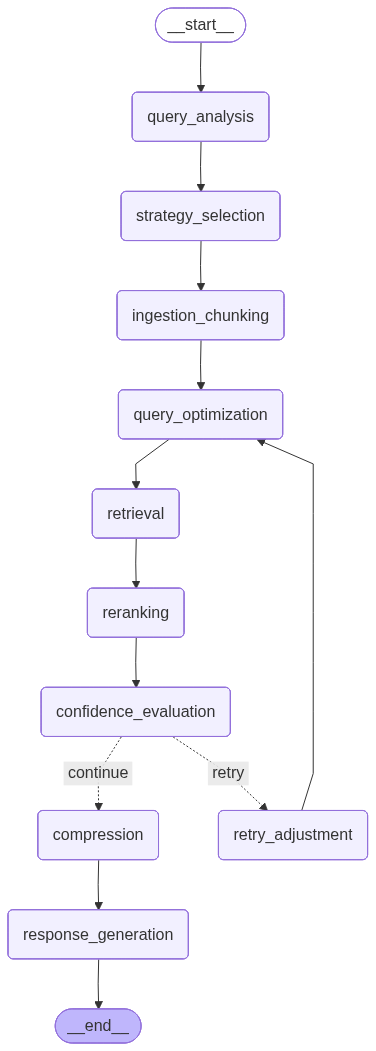

In [21]:
from IPython.display import Image, display
display(Image(rare_app.get_graph().draw_mermaid_png()))

## Section 15: Query Interface

The main entry point for running queries through the RARE pipeline.

In [22]:
def query_rare(q: str, config_override: dict = None, verbose: bool = True) -> dict:
    """Execute a query through the full RARE pipeline.

    Args:
        q: The query string.
        config_override: Optional config dict to override global CONFIG.
        verbose: If True, print explainability logs.

    Returns:
        dict with keys: answer, trace, state
    """
    t_start = time.time()

    initial_state = {
        "query": q,
        "config_override": config_override or CONFIG,
        "query_type": "",
        "detected_entities": [],
        "selected_chunkers": {},
        "selected_retrievers": {},
        "selected_optimizers": [],
        "selected_rerankers": {},
        "selected_compression": "",
        "selected_top_k_retrieval": CONFIG["top_k_retrieval"],
        "selected_top_k_reranked": CONFIG["top_k_reranked"],
        "optimized_queries": [],
        "retrieved_documents": [],
        "reranked_documents": [],
        "compressed_documents": [],
        "confidence_score": 0.0,
        "coverage_score": 0.0,
        "context_quality": 0.0,
        "retry_count": 0,
        "max_retries": CONFIG.get("max_retries", 3),
        "web_search_used": False,
        "web_search_documents": [],
        "final_answer": "",
        "trace": {},
        "node_latencies": {},
    }

    # Run the graph
    result = rare_app.invoke(initial_state)
    total_latency = time.time() - t_start

    # Build trace
    trace = PipelineTrace(
        query=q,
        query_type=result.get("query_type", ""),
        chunkers_used=list(result.get("selected_chunkers", {}).keys()),
        retrievers_used=list(result.get("selected_retrievers", {}).keys()),
        optimizers_used=result.get("selected_optimizers", []),
        rerankers_used=list(result.get("selected_rerankers", {}).keys()),
        compression_strategy=result.get("selected_compression", ""),
        confidence_score=result.get("confidence_score", 0),
        coverage_score=result.get("coverage_score", 0),
        context_quality=result.get("context_quality", 0),
        docs_retrieved=len(result.get("retrieved_documents", [])),
        docs_after_rerank=len(result.get("reranked_documents", [])),
        docs_final=len(result.get("compressed_documents", [])),
        retry_count=result.get("retry_count", 0),
        web_search_used=result.get("web_search_used", False),
        node_latencies=result.get("node_latencies", {}),
        total_latency=total_latency,
    )

    if verbose:
        explainability.log_query_analysis(trace, result.get("detected_entities"))
        explainability.log_retrieval(trace)
        explainability.log_reranking(trace, before=trace.docs_retrieved,
            avg_score=np.mean([d["score"] for d in result.get("reranked_documents", [{}])]) if result.get("reranked_documents") else 0)
        explainability.log_confidence(trace)
        explainability.log_summary(trace)
        explainability.log_langsmith(trace)

    return {
        "answer": result.get("final_answer", ""),
        "trace": trace,
        "state": result,
    }

print("[INTERFACE] query_rare() ready.")

[INTERFACE] query_rare() ready.


## Section 16: Evaluation (DeepEval)

Evaluates retrieval and generation quality using DeepEval with Ollama.

In [23]:
class RAREEvaluator:
    """Evaluation engine using DeepEval with local Ollama models."""

    def __init__(self):
        self.model = None
        try:
            from deepeval.models import OllamaModel
            import os
            os.environ["DEEPEVAL_WORKERS"] = "1"
            self.model = OllamaModel(
                model=OLLAMA_CONFIG["evaluation_model"],
                base_url="http://localhost:11434",
            )
            print("[EVAL] DeepEval + Ollama configured.")
        except Exception as e:
            print(f"[EVAL] DeepEval setup error (will use fallback): {e}")

    def evaluate(self, test_cases: List[dict]) -> pd.DataFrame:
        """Run evaluation on a list of test cases.

        Each test case: {query, answer, context_list, ground_truth}
        Returns a DataFrame with metric scores.
        """
        results = []
        if self.model is None:
            print("[EVAL] No evaluation model available. Using heuristic fallback.")
            return self._fallback_evaluate(test_cases)

        try:
            from deepeval.test_case import LLMTestCase
            from deepeval.metrics import (
                FaithfulnessMetric,
                AnswerRelevancyMetric,
                ContextualPrecisionMetric,
                ContextualRecallMetric,
                HallucinationMetric,
            )
        except ImportError as e:
            print(f"[EVAL] DeepEval import error: {e}")
            return self._fallback_evaluate(test_cases)

        metrics = {
            "faithfulness": FaithfulnessMetric(model=self.model, threshold=0.5),
            "answer_relevancy": AnswerRelevancyMetric(model=self.model, threshold=0.5),
            "contextual_precision": ContextualPrecisionMetric(model=self.model, threshold=0.5),
            "contextual_recall": ContextualRecallMetric(model=self.model, threshold=0.5),
            "hallucination": HallucinationMetric(model=self.model, threshold=0.5),
        }

        for i, tc in enumerate(test_cases):
            case = LLMTestCase(
                input=tc["query"],
                actual_output=tc["answer"],
                retrieval_context=tc.get("context_list", []),
                expected_output=tc.get("ground_truth", ""),
            )
            case.context = tc.get("context_list", [])
            row = {"query": tc["query"]}
            for mname, metric in metrics.items():
                try:
                    metric.measure(case)
                    row[mname] = metric.score
                except Exception as e:
                    row[mname] = None
                    print(f"[EVAL] {mname} error on case {i}: {e}")
            results.append(row)
            print(f"[EVAL] Case {i+1}/{len(test_cases)} complete.")

        return pd.DataFrame(results)

    def _fallback_evaluate(self, test_cases: List[dict]) -> pd.DataFrame:
        """Heuristic evaluation when DeepEval is unavailable."""
        results = []
        for tc in test_cases:
            answer = tc.get("answer", "").lower()
            context = " ".join(tc.get("context_list", [])).lower()
            query = tc.get("query", "").lower()

            # Simple heuristic metrics
            query_terms = set(query.split())
            answer_terms = set(answer.split())
            context_terms = set(context.split())

            relevancy = len(query_terms & answer_terms) / max(len(query_terms), 1)
            coverage = len(query_terms & context_terms) / max(len(query_terms), 1)

            results.append({
                "query": tc["query"],
                "answer_relevancy": min(relevancy * 1.5, 1.0),
                "context_coverage": min(coverage * 1.2, 1.0),
                "note": "heuristic_fallback",
            })
        return pd.DataFrame(results)

evaluator = RAREEvaluator()
print("[EVAL] Evaluator ready.")

[EVAL] DeepEval + Ollama configured.
[EVAL] Evaluator ready.


In [24]:
import json
QA_PATH = "/kaggle/input/datasets/shivanshcoding/rag-dataset-with-evaluation/QAonRBI.json"
def create_qa_lookup(filepath):
    print(f"📂 Loading data from {filepath}...")

    with open(filepath, "r", encoding="utf-8") as file:
        qa_list = json.load(file)


    print(f"✅ Successfully fetched {len(qa_list)} Q&A pairs!")
    return qa_list

my_rbi_list = create_qa_lookup(QA_PATH)
queries = [item["question"] for item in my_rbi_list]

📂 Loading data from /kaggle/input/datasets/shivanshcoding/rag-dataset-with-evaluation/QAonRBI.json...
✅ Successfully fetched 7 Q&A pairs!


In [25]:
def run_evaluation(queries: List[str] = None) -> pd.DataFrame:
    """Run evaluation on sample or provided queries."""
    if queries is None:
        queries = [
            "What is RAG?",
            "How does HNSW indexing work?",
            "What are the different chunking strategies?",
            "Compare dense and BM25 retrieval methods",
        ]

    test_cases = []
    for q in queries:
        print(f"\n[EVAL-RUN] Querying: {q}")
        result = query_rare(q, verbose=False)
        context_list = [d["content"] for d in result["state"].get("compressed_documents", [])]
        if not context_list:
            context_list = ["No retrieved context."]
        test_cases.append({
            "query": q,
            "answer": result["answer"],
            "context_list": context_list,
            "ground_truth": "",
        })

    df = evaluator.evaluate(test_cases)

    # Save results
    out_path = "/kaggle/working/evaluation_results.csv"
    df.to_csv(out_path, index=False)
    print(f"\n[EVAL] Results saved to {out_path}")
    print("\n--- EVALUATION RESULTS ---")
    print(df.to_string(index=False))
    print("--- END ---")
    return df

# Uncomment to run evaluation:
eval_df = run_evaluation(queries)


[EVAL-RUN] Querying: What does conducting financial activity as "principal business" mean?
[INGESTION] Chunkers match existing indices. Skipping re-indexing.
[RETRY] Attempt 1: top_k_retrieval=35, optimizers=['multi_query', 'query_expansion'], web_search=NO
[RETRY] Attempt 2: top_k_retrieval=40, optimizers=['multi_query', 'query_expansion', 'hyde'], web_search=NO
[CRAG] Final retry reached. Triggering web search for: 'What does conducting financial activity as "principal busine...'
[WEB-SEARCH] Retrieved 4 web results for: 'What does conducting financial activity as "principal busine...'
[CRAG] Added 4 web search results to context.
[RETRY] Attempt 3: top_k_retrieval=45, optimizers=['multi_query', 'query_expansion', 'hyde'], web_search=YES

[EVAL-RUN] Querying: Is it necessary that every NBFC should be registered with the Reserve Bank?
[INGESTION] Chunkers match existing indices. Skipping re-indexing.

[EVAL-RUN] Querying: What are the different types/categories of NBFCs registered wi

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

[EVAL] Case 7/7 complete.

[EVAL] Results saved to /kaggle/working/evaluation_results.csv

--- EVALUATION RESULTS ---
                                                                                                                                         query  faithfulness  answer_relevancy  contextual_precision  contextual_recall  hallucination
                                                                         What does conducting financial activity as "principal business" mean?      1.000000          1.000000              0.500000                1.0       0.500000
                                                                   Is it necessary that every NBFC should be registered with the Reserve Bank?      1.000000          1.000000              1.000000                1.0       0.444444
                                                            What are the different types/categories of NBFCs registered with the Reserve Bank?      0.900000          1.000000              1

## Section 17: Benchmarking

Systematically benchmarks different retrieval configurations and produces comparison reports.

In [30]:
class BenchmarkRunner:
    """Benchmarks RARE configurations across chunkers, retrievers, rerankers, and optimizers."""

    def __init__(self, queries: List[str] = None):
        self.queries = queries or [
            "What is RAG?",
            "How does semantic chunking work?",
            "Compare HNSW and IVF indexing",
            "What is cross-encoder reranking?",
        ]
        self.results = []

    def _run_config(self, name: str, config: dict) -> dict:
        """Run all queries with a specific config, return aggregate metrics."""
        latencies = []
        confidences = []
        doc_counts = []

        for q in self.queries:
            try:
                result = query_rare(q, config_override=config, verbose=False)
                trace = result["trace"]
                latencies.append(trace.total_latency)
                confidences.append(trace.confidence_score)
                doc_counts.append(trace.docs_final)
            except Exception as e:
                print(f"[BENCH] Error with '{name}' on '{q[:40]}': {e}")
                latencies.append(0)
                confidences.append(0)
                doc_counts.append(0)

        return {
            "configuration": name,
            "avg_latency": np.mean(latencies),
            "avg_confidence": np.mean(confidences),
            "avg_docs_final": np.mean(doc_counts),
            "queries_run": len(self.queries),
        }

    def benchmark_configurations(self) -> pd.DataFrame:
        """Run predefined benchmark configurations."""
        configs = {
            "Dense Only": {**CONFIG, "retrievers": {"dense": 1.0}, "query_optimizers": []},
            "BM25 Only": {**CONFIG, "retrievers": {"bm25": 1.0}, "query_optimizers": []},
            "Hybrid (Dense+BM25)": {**CONFIG, "retrievers": {"dense": 0.6, "bm25": 0.4}, "query_optimizers": []},
            "Hybrid + MultiQuery": {**CONFIG, "retrievers": {"dense": 0.6, "bm25": 0.4}, "query_optimizers": ["multi_query"]},
            "Hybrid + HyDE": {**CONFIG, "retrievers": {"dense": 0.6, "bm25": 0.4}, "query_optimizers": ["hyde"]},
            "Full Pipeline": CONFIG,
        }

        print("[BENCH] Starting benchmark run...")
        for name, cfg in configs.items():
            print(f"\n[BENCH] Configuration: {name}")
            result = self._run_config(name, cfg)
            self.results.append(result)
            print(f"  Avg Latency   : {result['avg_latency']:.3f}s")
            print(f"  Avg Confidence: {result['avg_confidence']:.4f}")

        df = pd.DataFrame(self.results)
        return df

    def generate_reports(self, df: pd.DataFrame):
        """Generate benchmark output files."""
        # benchmark_results.csv
        df.to_csv("/kaggle/working/benchmark_results.csv", index=False)

        # leaderboard.csv (sorted by confidence)
        leaderboard = df.sort_values("avg_confidence", ascending=False).reset_index(drop=True)
        leaderboard.index += 1
        leaderboard.index.name = "rank"
        leaderboard.to_csv("/kaggle/working/leaderboard.csv")

        # comparison_report.md
        report = "# RARE Benchmark Report\n\n"
        report += f"Generated: {time.strftime('%Y-%m-%d %H:%M:%S')}\n\n"
        report += "## Leaderboard\n\n"
        report += "| Rank | Configuration | Avg Latency (s) | Avg Confidence | Avg Docs |\n"
        report += "|------|--------------|-----------------|----------------|----------|\n"
        for i, row in leaderboard.iterrows():
            report += f"| {i} | {row['configuration']} | {row['avg_latency']:.3f} | {row['avg_confidence']:.4f} | {row['avg_docs_final']:.1f} |\n"
        report += "\n## Configuration Details\n\n"
        report += "Each configuration was tested against the same query set.\n"
        report += f"Queries: {len(self.queries)}\n"

        with open("/kaggle/working/comparison_report.md", "w") as f:
            f.write(report)

        print("\n--- BENCHMARK OUTPUTS ---")
        print("benchmark_results.csv  : /kaggle/working/benchmark_results.csv")
        print("leaderboard.csv        : /kaggle/working/leaderboard.csv")
        print("comparison_report.md   : /kaggle/working/comparison_report.md")
        print("--- END ---")

        print("\n--- LEADERBOARD ---")
        print(leaderboard.to_string())
        print("--- END ---")

# Uncomment to run benchmarks:
bench = BenchmarkRunner(queries)
bench_df = bench.benchmark_configurations()
bench.generate_reports(bench_df)

[BENCH] Starting benchmark run...

[BENCH] Configuration: Dense Only
[INGESTION] Chunkers match existing indices. Skipping re-indexing.
[RETRY] Attempt 1: top_k_retrieval=35, optimizers=['query_expansion'], web_search=NO
[RETRY] Attempt 2: top_k_retrieval=40, optimizers=['query_expansion', 'hyde'], web_search=NO
[CRAG] Final retry reached. Triggering web search for: 'What does conducting financial activity as "principal busine...'
[WEB-SEARCH] Retrieved 4 web results for: 'What does conducting financial activity as "principal busine...'
[CRAG] Added 4 web search results to context.
[RETRY] Attempt 3: top_k_retrieval=45, optimizers=['query_expansion', 'hyde'], web_search=YES
[INGESTION] Chunkers match existing indices. Skipping re-indexing.
[INGESTION] Chunkers match existing indices. Skipping re-indexing.
[INGESTION] Chunkers match existing indices. Skipping re-indexing.
[INGESTION] Chunkers match existing indices. Skipping re-indexing.
[INGESTION] Chunkers match existing indices. Skip

## Section 18: Interactive Querying

Run queries through the RARE pipeline with full explainability output.

In [31]:
# ---- Example 1: Manual Mode Query ----
print("=" * 70)
print("RARE ENGINE - MANUAL MODE QUERY")
print("=" * 70)

result = query_rare(queries[2])

print("\n" + "=" * 70)
print("GENERATED ANSWER:")
print("=" * 70)
print(result["answer"])

RARE ENGINE - MANUAL MODE QUERY
[INGESTION] Chunkers match existing indices. Skipping re-indexing.

--- QUERY ANALYSIS ---
Query              : What are the different types/categories of NBFCs registered with the Reserve Bank?
Detected Query Type: factual
Entities           : ['NBFCs', 'Reserve Bank']
Selected Chunkers  : ['semantic', 'parent_child', 'recursive']
Selected Retrievers: ['dense', 'bm25', 'metadata']
Selected Optimizers: ['multi_query']
Selected Rerankers : ['bge', 'cross_encoder']
Selected Compress. : contextual
--- END ---

--- RETRIEVAL EXECUTION ---
Documents Retrieved     : 30
Fusion Strategy         : Reciprocal Rank Fusion (RRF)
Retriever Contributions : {}
Latency                 : 2.328s
--- END ---

--- RERANKING ---
Documents Before : 30
Documents After  : 15
Average Score    : 0.7125
Latency          : 2.476s
--- END ---

--- CONFIDENCE ANALYSIS ---
Coverage Score        : 0.7500
Context Quality Score : 0.9503
Retrieval Confidence  : 0.8301
Retry Required      

In [32]:
# ---- Example 2: Agent Mode Query ----
print("=" * 70)
print("RARE ENGINE - AGENT MODE QUERY")
print("=" * 70)

agent_config = {**CONFIG, "agent_mode": True}
result_agent = query_rare(
    queries[0],
    config_override=agent_config,
)

print("\n" + "=" * 70)
print("GENERATED ANSWER:")
print("=" * 70)
print(result_agent["answer"])

RARE ENGINE - AGENT MODE QUERY
[INGESTION] Agent selected different chunkers: {'semantic', 'parent_child'} vs indexed: {'semantic', 'parent_child', 'recursive'}
[INGESTION-AGENT] Running ingestion for chunkers: ['semantic', 'parent_child']
[VECTOR] Deleted collection 'rare_semantic'
[VECTOR] Deleted collection 'rare_parent_child'
[VECTOR] Deleted collection 'rare_recursive'


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[CHUNK]        semantic:   679 chunks (140.73s)
[CHUNK]    parent_child:  2633 chunks (0.07s)
[VECTOR] Collection 'rare_semantic': 679 vectors (dim=1024)
[VECTOR] Collection 'rare_parent_child': 2633 vectors (dim=1024)
[BM25] Index 'semantic': 679 documents
[BM25] Index 'parent_child': 2633 documents
[INGESTION-AGENT] Indexing complete. Collections: ['semantic', 'parent_child']
[RETRY] Attempt 1: top_k_retrieval=35, optimizers=['multi_query', 'query_expansion'], web_search=NO
[RETRY] Attempt 2: top_k_retrieval=40, optimizers=['multi_query', 'query_expansion', 'hyde'], web_search=NO
[CRAG] Final retry reached. Triggering web search for: 'What does conducting financial activity as "principal busine...'
[WEB-SEARCH] Retrieved 4 web results for: 'What does conducting financial activity as "principal busine...'
[CRAG] Added 4 web search results to context.
[RETRY] Attempt 3: top_k_retrieval=45, optimizers=['multi_query', 'query_expansion', 'hyde'], web_search=YES

--- QUERY ANALYSIS ---
Que

In [ ]:
# ---- Example 3: Run Evaluation ----
# Uncomment the line below to run full evaluation
eval_df = run_evaluation(queries)
print("[INFO] Uncomment the line above to run evaluation.")
print("[INFO] Results will be saved to /kaggle/working/evaluation_results.csv")

In [ ]:
# ---- Example 4: Run Benchmarks ----
# Uncomment the lines below to run full benchmarks
bench = BenchmarkRunner(queries)
bench_df = bench.benchmark_configurations()
bench.generate_reports(bench_df)
print("[INFO] Uncomment the lines above to run benchmarks.")
print("[INFO] Results will be saved to /kaggle/working/benchmark_results.csv")
print("[INFO] Leaderboard will be saved to /kaggle/working/leaderboard.csv")

## End of Notebook

RARE: Research-Grade Agentic Retrieval Engine

To customize the pipeline, modify the `CONFIG` and `OLLAMA_CONFIG` dictionaries in Section 3.
No source code changes are required to change system behavior.